In [1]:
# For Data Processing
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from PIL import Image, ImageEnhance
import gc

# For ML Models
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.models import *
from tensorflow.keras.metrics import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.applications import *
from tensorflow.keras.preprocessing.image import load_img
import keras
from keras import layers
from keras import ops

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Miscellaneous
from tqdm import tqdm
import os
import random

2025-10-19 15:58:01.202758: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760889481.420712      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760889481.473290      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
!pip install tensorflow==2.12.0 tf-keras-vis==0.8.0

ERROR: Ignored the following versions that require a different python version: 0.2.0 Requires-Python >=3.5, <3.8; 0.2.1 Requires-Python >=3.5, <3.8; 0.2.3 Requires-Python >=3.5, <3.8; 0.2.4 Requires-Python >=3.5, <=3.8; 0.2.5 Requires-Python >=3.5, <3.9; 0.3.1 Requires-Python >=3.5, <3.9; 0.3.2 Requires-Python >=3.5, <3.9; 0.3.3 Requires-Python >=3.5, <3.9; 0.4.0 Requires-Python >=3.5, <3.9; 0.5.0 Requires-Python >=3.5, <3.9; 0.5.2 Requires-Python >=3.5, <3.9; 0.5.3 Requires-Python >=3.5, <3.9; 0.5.4 Requires-Python >=3.5, <3.9; 0.5.5 Requires-Python >=3.6, <3.9; 0.6.0 Requires-Python >=3.6, <3.10; 0.6.1 Requires-Python >=3.6, <3.10; 0.6.2 Requires-Python >=3.6, <3.10; 0.7.0 Requires-Python >=3.6, <3.10; 0.7.1 Requires-Python >=3.6, <3.10; 0.7.2 Requires-Python >=3.6, <3.10; 0.8.0 Requires-Python >=3.6, <3.10; 0.8.1 Requires-Python >=3.7, <3.11
ERROR: Could not find a version that satisfies the requirement tf-keras-vis==0.8.0 (from versions: 0.0.1, 0.1.0, 0.8.2, 0.8.3, 0.8.4, 0.8.5, 0.

In [3]:
import os
from sklearn.utils import shuffle

train_dir = '/kaggle/input/elite-lab-dataset/tumordata/Training/'

train_paths = []
train_labels = []

# 1️⃣ Sort class folders alphabetically
class_folders = sorted([f for f in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, f))])

print("✅ Classes in training set:", class_folders)

# 2️⃣ Loop through folders and images, store string labels
for label in class_folders:
    folder_path = os.path.join(train_dir, label)
    images = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    for img in images:
        train_paths.append(os.path.join(folder_path, img))
        train_labels.append(label)  # store string label

# 3️⃣ Shuffle dataset (optional)
train_paths, train_labels = shuffle(train_paths, train_labels, random_state=42)

print("✅ Number of training images:", len(train_paths))

✅ Classes in training set: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
✅ Number of training images: 13927


In [4]:
import os
from sklearn.utils import shuffle

test_dir = '/kaggle/input/elite-lab-dataset/tumordata/Testing'
test_paths = []
test_labels = []

# 1️⃣ Sort class folders alphabetically (same order as training)
class_folders = sorted([f for f in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, f))])

print("✅ Classes in test set:", class_folders)

# 2️⃣ Loop through folders and images, store string labels
for label in class_folders:
    folder_path = os.path.join(test_dir, label)
    images = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    for img in images:
        test_paths.append(os.path.join(folder_path, img))
        test_labels.append(label)  # store **string label**

# 3️⃣ Shuffle dataset (optional)
test_paths, test_labels = shuffle(test_paths, test_labels, random_state=42)

print("✅ Number of test images:", len(test_paths))

✅ Classes in test set: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
✅ Number of test images: 3961


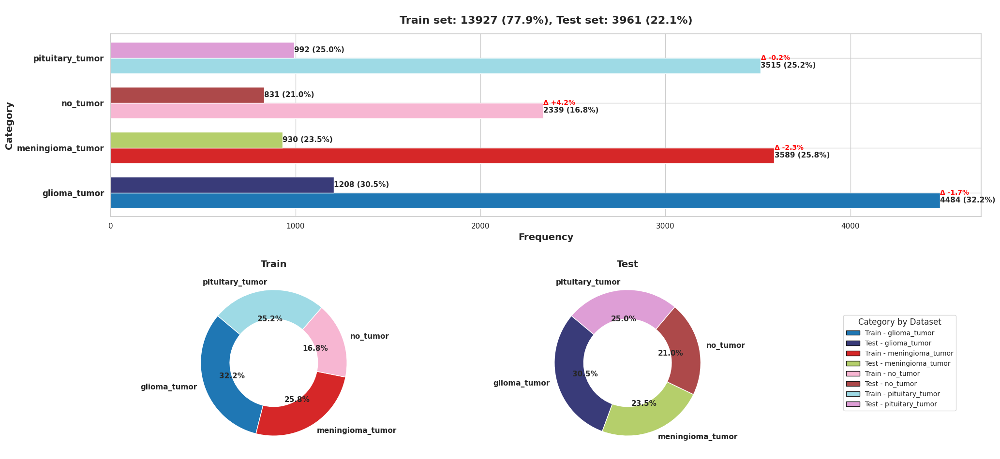

✅ Figure saved as 'Dataset_Distribution.png'


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from matplotlib.patches import Patch
import matplotlib

def plot_distribution(train_array, test_array=None, title="Category Distribution", output_file="dataset_overview.png"):
    sns.set_theme(style="whitegrid")

    # ---------------- Compute frequencies ----------------
    def compute_freq(array):
        hist = Counter(array)
        categories = sorted(hist.keys(), key=lambda x: hist[x], reverse=True)
        freqs = [hist[cat] for cat in categories]
        df = pd.DataFrame({"Category": categories, "Frequency": freqs})
        df['Percentage'] = df['Frequency'] / df['Frequency'].sum() * 100
        return df

    train_df = compute_freq(train_array)
    total_train = len(train_array)

    if test_array is not None:
        test_df = compute_freq(test_array)
        total_test = len(test_array)
        merged_df = pd.merge(train_df, test_df, on="Category", how="outer", suffixes=("_train", "_test")).fillna(0)
        categories = merged_df['Category'].tolist()
        freqs_train = merged_df['Frequency_train'].tolist()
        freqs_test = merged_df['Frequency_test'].tolist()
        perc_train = merged_df['Percentage_train'].tolist()
        perc_test = merged_df['Percentage_test'].tolist()
        diff_perc = [p_test - p_train for p_train, p_test in zip(perc_train, perc_test)]
        ratio_text = f"Train set: {total_train} ({total_train/(total_train+total_test)*100:.1f}%), " \
                     f"Test set: {total_test} ({total_test/(total_train+total_test)*100:.1f}%)"
    else:
        categories = train_df['Category'].tolist()
        freqs_train = train_df['Frequency'].tolist()
        perc_train = train_df['Percentage'].tolist()
        freqs_test = perc_test = diff_perc = None
        ratio_text = f"Train set: {total_train} (100%)"

    num_cats = len(categories)
    colors_train = matplotlib.cm.tab20(np.linspace(0, 1, num_cats))
    colors_test = matplotlib.cm.tab20b(np.linspace(0, 1, num_cats))

    # ---------------- Layout ----------------
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 3, height_ratios=[2, 2], width_ratios=[2, 2, 1], hspace=0.3, wspace=0.1)

    # ---------------- Horizontal Bar Chart (Top row) ----------------
    ax_bar = fig.add_subplot(gs[0, :])
    y_pos = np.arange(num_cats)
    bar_width = 0.35

    if test_array is not None:
        ax_bar.barh(y_pos - bar_width/2, freqs_train, height=bar_width, color=colors_train)
        ax_bar.barh(y_pos + bar_width/2, freqs_test, height=bar_width, color=colors_test)
        for i, (f_train, f_test, p_train, p_test, d) in enumerate(zip(freqs_train, freqs_test, perc_train, perc_test, diff_perc)):
            ax_bar.text(f_train + 0.5, i - bar_width/2, f"{f_train} ({p_train:.1f}%)", va='center', fontsize=11, fontweight='bold')
            ax_bar.text(f_test + 0.5, i + bar_width/2, f"{f_test} ({p_test:.1f}%)", va='center', fontsize=11, fontweight='bold')
            ax_bar.text(max(f_train, f_test)+2, i, f"Δ {d:+.1f}%", va='center', fontsize=10, color='red', fontweight='bold')
    else:
        ax_bar.barh(categories, freqs_train, color=colors_train)
        for i, (f, p) in enumerate(zip(freqs_train, perc_train)):
            ax_bar.text(f + 0.5, i, f"{f} ({p:.1f}%)", va='center', fontsize=11, fontweight='bold')

    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels(categories, fontsize=12, fontweight='bold')
    ax_bar.set_xlabel("Frequency", fontsize=14, fontweight='bold')
    ax_bar.set_ylabel("Category", fontsize=14, fontweight='bold')
    ax_bar.set_title("", fontsize=16, fontweight='bold')

    # ---------------- Donut Charts and Legend (Bottom row) ----------------
    def draw_donut(ax, freqs, categories, colors, set_name="Train"):
        wedges, texts, autotexts = ax.pie(freqs, labels=categories, autopct='%1.1f%%',
                                          startangle=140, colors=colors,
                                          wedgeprops=dict(width=0.4, edgecolor='w'),
                                          textprops={'fontsize':11, 'fontweight':'bold'})
        ax.set_title(f"{set_name}", fontsize=14, fontweight='bold')

    # Train Donut
    ax_donut_train = fig.add_subplot(gs[1, 0])
    draw_donut(ax_donut_train, freqs_train, categories, colors_train, set_name="Train")

    # Test Donut
    ax_donut_test = fig.add_subplot(gs[1, 1])
    if test_array is not None:
        draw_donut(ax_donut_test, freqs_test, categories, colors_test, set_name="Test")
    else:
        ax_donut_test.axis('off')

    # Legend
    ax_legend = fig.add_subplot(gs[1, 2])
    ax_legend.axis('off')
    legend_elements = []
    if test_array is not None:
        for i, cat in enumerate(categories):
            legend_elements.append(Patch(facecolor=colors_train[i], edgecolor='k', label=f"Train - {cat}"))
            legend_elements.append(Patch(facecolor=colors_test[i], edgecolor='k', label=f"Test - {cat}"))
    else:
        for i, cat in enumerate(categories):
            legend_elements.append(Patch(facecolor=colors_train[i], edgecolor='k', label=f"Train - {cat}"))
    ax_legend.legend(handles=legend_elements, fontsize=10, title="Category by Dataset", title_fontsize=12, loc='center')

    # ---------------- Overall Title ----------------
    fig.suptitle(f"{title}\n{ratio_text}", fontsize=16, fontweight='bold')

    # Adjust layout manually for compactness
    plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05, hspace=0.25, wspace=0.05)

    # ---------------- Save Figure ----------------
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Figure saved as '{output_file}'")

# Example usage:
plot_distribution(train_labels, test_labels, title="", output_file="Dataset_Distribution.png")

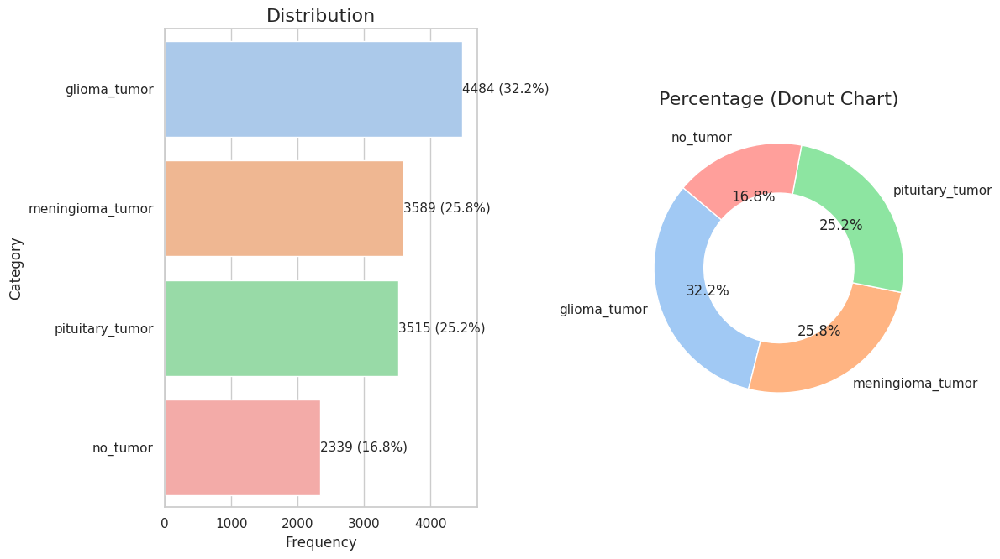

Figure saved as 'train.png'


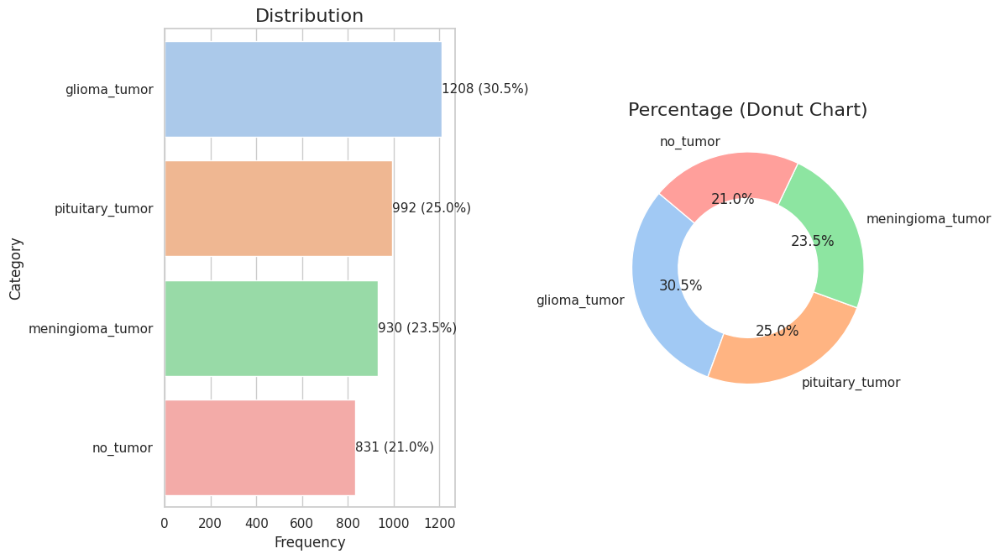

Figure saved as 'test.png'


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import plotly.express as px

def plot_distribution(array, title="Category Distribution", interactive=False, name = "set.png"):
    """
    Plots the distribution of categorical data as:
    - Horizontal bar chart
    - Donut chart (pie with a hole)
    Can also produce an interactive Plotly chart.

    Parameters:
    - array: list or array of categorical values
    - title: string, title of the plot
    - interactive: bool, if True, shows Plotly interactive chart
    """
    # Calculate frequencies
    hist = Counter(array)
    categories = sorted(hist.keys(), key=lambda x: hist[x], reverse=True)
    frequencies = [hist[cat] for cat in categories]
    df = pd.DataFrame({"Category": categories, "Frequency": frequencies})
    df['Percentage'] = df['Frequency'] / df['Frequency'].sum() * 100

    if interactive:
        # Interactive donut chart with Plotly
        fig = px.pie(df, 
                     names='Category', 
                     values='Frequency', 
                     title=title, 
                     hole=0.4,  # donut chart
                     color='Category',
                     color_discrete_sequence=px.colors.qualitative.Pastel)
        fig.update_traces(textposition='inside', textinfo='percent+label')
        fig.show()
    else:
        # Static matplotlib/seaborn plot
        sns.set_theme(style="whitegrid")
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))

        # Horizontal Bar Chart
        sns.barplot(x="Frequency", y="Category", data=df, palette="pastel", ax=ax1)
        ax1.set_title("Distribution", fontsize=16)
        ax1.set_xlabel("Frequency")
        ax1.set_ylabel("Category")

        # Add count annotations
        for i, (freq, perc) in enumerate(zip(df['Frequency'], df['Percentage'])):
            ax1.text(freq + 0.5, i, f"{freq} ({perc:.1f}%)", va='center', fontsize=11)

        # Donut Chart
        colors = sns.color_palette("pastel", n_colors=len(categories))
        wedges, texts, autotexts = ax2.pie(
            frequencies, labels=categories, autopct="%1.1f%%",
            startangle=140, colors=colors, wedgeprops=dict(width=0.4)
        )
        ax2.set_title("Percentage (Donut Chart)", fontsize=16)

        # Overall title
        fig.suptitle(title, fontsize=18)
        plt.tight_layout()
        output_filename = name
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Figure saved as '{output_filename}'")


# =====================
# Example usage:
# train_labels = ['pituitary_tumor', 'no_tumor', 'glioma_tumor', 'meningioma_tumor', ...]
plot_distribution(train_labels, title="", interactive=False, name = "train.png")
plot_distribution(test_labels, title="", interactive=False, name = "test.png")

In [7]:
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
    image = np.array(image)/255.0
    return image

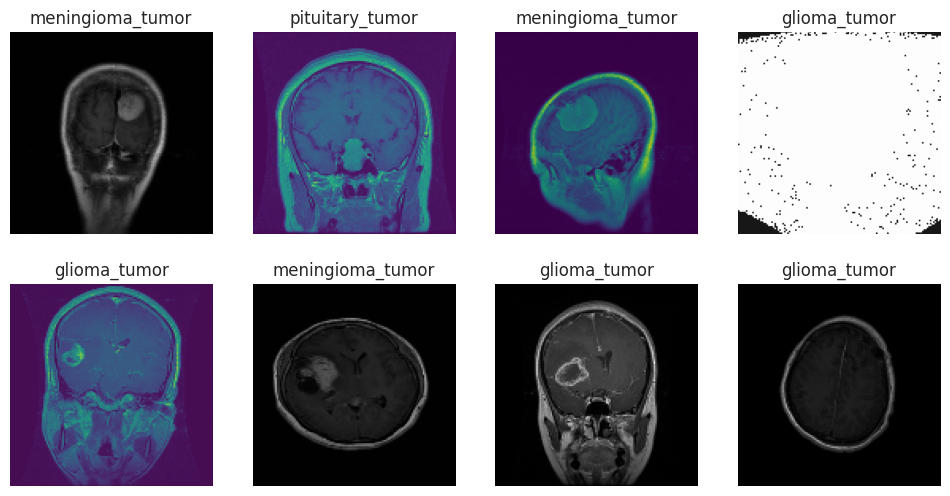

In [8]:
IMAGE_SIZE = 128

def open_images(paths):
    '''
    Given a list of paths to images, this function returns the images as arrays (after augmenting them)
    '''
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE,IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

images = open_images(train_paths[50:59])
labels = train_labels[50:59]
fig = plt.figure(figsize=(12, 6))
for x in range(1, 9):
    fig.add_subplot(2, 4, x)
    plt.axis('off')
    plt.title(labels[x])
    plt.imshow(images[x])
plt.rcParams.update({'font.size': 10})
plt.show()

In [9]:
unique_labels = os.listdir(train_dir)

def encode_label(labels):
    encoded = []
    for x in labels:
        encoded.append(unique_labels.index(x))
    return np.array(encoded)

def decode_label(labels):
    decoded = []
    for x in labels:
        decoded.append(unique_labels[x])
    return np.array(decoded)

def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for x in range(0, len(paths), batch_size):
            batch_paths = paths[x:x+batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[x:x+batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

In [10]:
# !pip install vit-keras

In [11]:
# from tensorflow.keras import Sequential, Input
# from tensorflow.keras.layers import Dense, Dropout, Flatten
# from vit_keras import vit
# import tensorflow as tf

# # Load Vision Transformer (ViT-B16 or B32 are common choices)
# base_model = vit.vit_b16(
#     image_size=IMAGE_SIZE,
#     activation='softmax',
#     pretrained=True,
#     include_top=False,
#     pretrained_top=False
# )

# # Freeze all layers
# for layer in base_model.layers:
#     layer.trainable = False

# # Optionally unfreeze last few layers for fine-tuning
# for layer in base_model.layers[-3:]:
#     layer.trainable = True

# # Build classifier model
# model = Sequential()
# model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
# model.add(base_model)
# model.add(Dropout(0.3))
# model.add(Dense(32, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(len(unique_labels), activation='softmax'))

In [12]:
base_model = Xception(input_shape=(IMAGE_SIZE,IMAGE_SIZE,3), include_top=False, weights='imagenet')
# Set all layers to non-trainable
for layer in base_model.layers:
    layer.trainable = False
# Set the last vgg block to trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(unique_labels), activation='softmax'))

I0000 00:00:1760889504.131502      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [13]:
# from tensorflow.keras import Input, Model
# from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# # Input Layer
# input_layer = Input(shape=(128, 128, 3))

# # Convolutional Block 1
# x = Conv2D(32, (3,3), activation='relu')(input_layer)
# x = MaxPooling2D((2,2))(x)
# x = BatchNormalization()(x)
# x = Dropout(0.2)(x)

# # Convolutional Block 2
# x = Conv2D(64, (3,3), activation='relu')(x)
# x = MaxPooling2D((2,2))(x)
# x = BatchNormalization()(x)
# x = Dropout(0.2)(x)

# # Convolutional Block 3
# x = Conv2D(128, (3,3), activation='relu', name='target_conv_layer')(x)
# x = MaxPooling2D((2,2))(x)
# x = BatchNormalization()(x)

# # Fully Connected Block
# x = Flatten()(x)
# x = Dense(128, activation='relu')(x)
# x = Dropout(0.5)(x)

# # Output Layer
# output_layer = Dense(4, activation='softmax')(x)

# # Build the model
# model = Model(inputs=input_layer, outputs=output_layer)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 4, 4, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,056,428 (95.58 MB)

 Trainable params: 7,358,596 (28.07 MB)

 Non-trainable params: 17,697,832 (67.51 MB)

In [15]:
#keras.utils.plot_model(model, show_shapes=True)

In [16]:
model.compile(optimizer=Adam(learning_rate=0.0001),
             loss='sparse_categorical_crossentropy',
             metrics=['sparse_categorical_accuracy'])

In [17]:
batch_size = 8
steps = int(len(train_paths)/batch_size)
epochs = 20
NUM_CLASSES = 4  # 4-class classification
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps, verbose = 2)

Epoch 1/20


I0000 00:00:1760889517.533938      66 service.cc:148] XLA service 0x7b6800004560 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760889517.534730      66 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1760889518.493408      66 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1760889522.491191      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1740/1740 - 108s - 62ms/step - loss: 0.5011 - sparse_categorical_accuracy: 0.8105
Epoch 2/20
1740/1740 - 58s - 33ms/step - loss: 0.2196 - sparse_categorical_accuracy: 0.9149
Epoch 3/20
1740/1740 - 53s - 31ms/step - loss: 0.1115 - sparse_categorical_accuracy: 0.9596
Epoch 4/20
1740/1740 - 53s - 30ms/step - loss: 0.0694 - sparse_categorical_accuracy: 0.9751
Epoch 5/20
1740/1740 - 53s - 30ms/step - loss: 0.0561 - sparse_categorical_accuracy: 0.9801
Epoch 6/20
1740/1740 - 54s - 31ms/step - loss: 0.0480 - sparse_categorical_accuracy: 0.9836
Epoch 7/20
1740/1740 - 53s - 31ms/step - loss: 0.0396 - sparse_categorical_accuracy: 0.9869
Epoch 8/20
1740/1740 - 54s - 31ms/step - loss: 0.0357 - sparse_categorical_accuracy: 0.9881
Epoch 9/20
1740/1740 - 53s - 31ms/step - loss: 0.0317 - sparse_categorical_accuracy: 0.9891
Epoch 10/20
1740/1740 - 54s - 31ms/step - loss: 0.0273 - sparse_categorical_accuracy: 0.9906
Epoch 11/20
1740/1740 - 54s - 31ms/step - loss: 0.0230 - sparse_categorical_accuracy: 0.9

496it [01:13,  6.78it/s]


Precision: 0.8931
Recall: 0.8922
F1-score: 0.8915
Accuracy: 0.8922


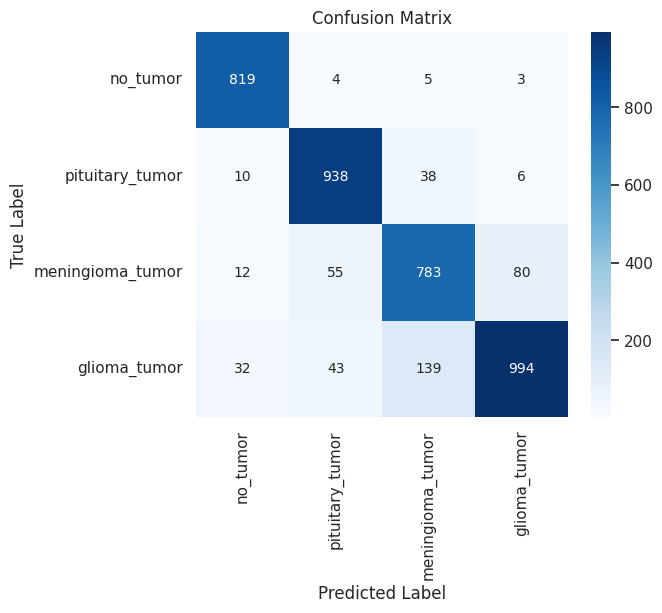

1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 36ms/step
1/1 - 0s - 43ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 39ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 39ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 40ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 36ms/step
1/1 - 0s - 37

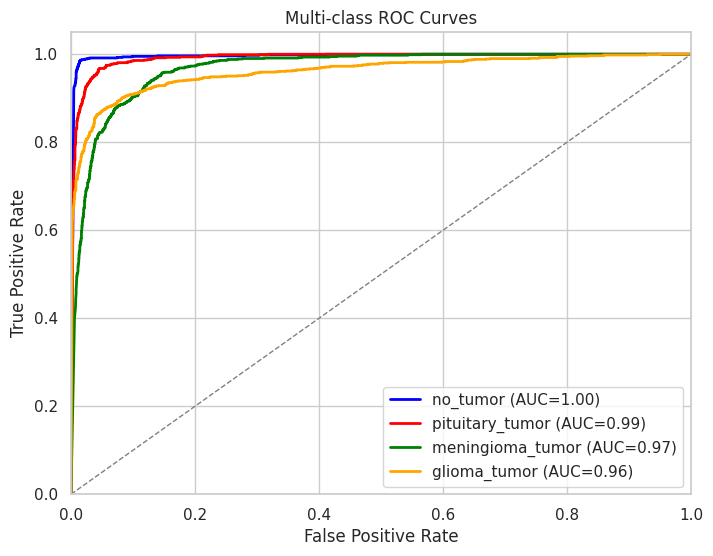

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------- Evaluation ----------------
batch_size = 8
steps = int(len(test_paths)/batch_size)
y_pred = []
y_true = []

for x, y in tqdm(datagen(test_paths, test_labels, batch_size=batch_size, epochs=1), total=steps):
    pred_prob = model.predict(x, verbose=0)  # keep probabilities for ROC
    pred = np.argmax(pred_prob, axis=-1)
    
    y_pred.extend(pred)
    y_true.extend(y)

# ---------------- Metrics ----------------
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
acc = np.mean(np.array(y_pred) == np.array(y_true))  # ✅ accuracy line

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Accuracy: {acc:.4f}")  # ✅ print accuracy

# ---------------- Confusion Matrix ----------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# ---------------- ROC Curves ----------------
# Convert to one-hot for ROC
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

# If you need probabilities for each batch, stack them
# Assuming pred_prob from last batch for simplicity; better: collect all batch probabilities
# Here we recompute them on test set:
y_pred_prob = []
for x, _ in datagen(test_paths, test_labels, batch_size=batch_size, epochs=1):
    prob = model.predict(x, verbose=2)
    y_pred_prob.append(prob)
y_pred_prob = np.vstack(y_pred_prob)

plt.figure(figsize=(8,6))
colors = ['blue', 'red', 'green', 'orange']  # extend if more classes
for i, cls_name in enumerate(unique_labels):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'{cls_name} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], color='grey', lw=1, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves')
plt.legend(loc='lower right')
plt.show()


# Federated Learning Based transfer Learning enabled VGG-16 Model

In [19]:
# import tensorflow as tf
# import numpy as np
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# import keras
# keras.config.enable_unsafe_deserialization()


# # Define the number of clients and the number of training rounds
# NUM_CLIENTS = 5
# NUM_ROUNDS = 3


# # Define the clients and their data
# clients = []
# for i in range(NUM_CLIENTS):
#     client_data = train_paths[i * (len(train_paths) // NUM_CLIENTS):(i + 1) * (len(train_paths) // NUM_CLIENTS)]
#     client_labels = train_labels[i * (len(train_labels) // NUM_CLIENTS):(i + 1) * (len(train_labels) // NUM_CLIENTS)]
#     clients.append((client_data, client_labels))

# # Federated learning loop
# for round_num in range(NUM_ROUNDS):

#     # Select clients
#     selected_client_indices = np.random.choice(len(clients), size=int(NUM_CLIENTS * 0.5), replace=False)
#     selected_clients = [clients[i] for i in selected_client_indices]

#     # Transmit the global model to the selected clients
#     for client in selected_clients:
#         client_model = tf.keras.models.clone_model(model)
#         client_model.set_weights(model.get_weights())
  
#         # Compile the client model
#         client_model.compile(optimizer=Adam(learning_rate=0.0001),
#         loss='sparse_categorical_crossentropy',
#         metrics=['sparse_categorical_accuracy'])

#         steps_per_epoch = int(len(client[0]) / 10)
        

#         client_model.fit(datagen(client[0],client[1], batch_size=batch_size, epochs=epochs),
#                          epochs=5, steps_per_epoch=steps_per_epoch, verbose = 2)

#         # Train locally
#         steps_per_epoch = int(len(client[0]) / 10)

#         # Aggregate the model
#         new_weights = []
#         for layer_index in range(len(model.get_weights())):
#             new_layer_weights = np.mean([client_model.get_weights()[layer_index], model.get_weights()[layer_index]], axis=0)
#             new_weights.append(new_layer_weights)
#         model.set_weights(new_weights)
        
# batch_size = 8
# steps = int(len(test_paths)/batch_size)
# y_pred = []
# y_true = []
# for x,y in tqdm(datagen(test_paths, test_labels, batch_size=batch_size, epochs=1), total=steps):
#     pred = model.predict(x)
#     pred = np.argmax(pred, axis=-1)
#     for i in decode_label(pred):
#         y_pred.append(i)
#     for i in decode_label(y):
#         y_true.append(i)

# #     # Evaluate the global model
# #     test_loss, test_acc = model.evaluate(test_paths, test_labels,)
# #     print('Round {}: Test accuracy = {}'.format(round_num, test_acc))

# # # Fine-tune the model
# # model.fit(test_paths, test_labels, epochs=1, batch_size=32)

# # Deploy the model
# model.save('my_model.h5')


--- Federated Round 1 ---
Training client 0...
Epoch 1/5
174/174 - 15s - 83ms/step - loss: 0.0078 - sparse_categorical_accuracy: 0.9986
Epoch 2/5
174/174 - 5s - 30ms/step - loss: 0.0112 - sparse_categorical_accuracy: 0.9986
Epoch 3/5
174/174 - 5s - 30ms/step - loss: 3.8354e-04 - sparse_categorical_accuracy: 1.0000
Epoch 4/5
174/174 - 5s - 30ms/step - loss: 0.0030 - sparse_categorical_accuracy: 0.9993
Epoch 5/5
174/174 - 5s - 31ms/step - loss: 2.4309e-04 - sparse_categorical_accuracy: 1.0000
Training client 3...
Epoch 1/5
174/174 - 15s - 87ms/step - loss: 0.0079 - sparse_categorical_accuracy: 0.9993
Epoch 2/5
174/174 - 5s - 31ms/step - loss: 0.0011 - sparse_categorical_accuracy: 1.0000
Epoch 3/5
174/174 - 5s - 31ms/step - loss: 2.2024e-04 - sparse_categorical_accuracy: 1.0000
Epoch 4/5
174/174 - 6s - 32ms/step - loss: 0.0092 - sparse_categorical_accuracy: 0.9986
Epoch 5/5
174/174 - 5s - 31ms/step - loss: 0.0028 - sparse_categorical_accuracy: 0.9993
Training client 7...
Epoch 1/5
174/17

496it [00:54,  9.07it/s]                         


Round 1 loss: 0.8970
Metrics: Acc=0.8970, Prec=0.9007, Recall=0.8970, F1=0.8968, AUC=0.9778

--- Federated Round 2 ---
Training client 0...
Epoch 1/5
174/174 - 15s - 85ms/step - loss: 0.0070 - sparse_categorical_accuracy: 0.9993
Epoch 2/5
174/174 - 5s - 29ms/step - loss: 0.0288 - sparse_categorical_accuracy: 0.9971
Epoch 3/5
174/174 - 5s - 30ms/step - loss: 1.9933e-04 - sparse_categorical_accuracy: 1.0000
Epoch 4/5
174/174 - 5s - 30ms/step - loss: 9.9113e-05 - sparse_categorical_accuracy: 1.0000
Epoch 5/5
174/174 - 5s - 30ms/step - loss: 3.3731e-04 - sparse_categorical_accuracy: 1.0000
Training client 1...
Epoch 1/5
174/174 - 15s - 87ms/step - loss: 0.0097 - sparse_categorical_accuracy: 0.9986
Epoch 2/5
174/174 - 6s - 32ms/step - loss: 0.0037 - sparse_categorical_accuracy: 0.9978
Epoch 3/5
174/174 - 6s - 32ms/step - loss: 0.0125 - sparse_categorical_accuracy: 0.9957
Epoch 4/5
174/174 - 6s - 32ms/step - loss: 3.0062e-04 - sparse_categorical_accuracy: 1.0000
Epoch 5/5
174/174 - 5s - 31ms

496it [00:54,  9.05it/s]                         


Round 2 loss: 0.9010
Metrics: Acc=0.9010, Prec=0.9038, Recall=0.9010, F1=0.9009, AUC=0.9782

--- Federated Round 3 ---
Training client 0...
Epoch 1/5
174/174 - 16s - 92ms/step - loss: 0.0086 - sparse_categorical_accuracy: 0.9986
Epoch 2/5
174/174 - 5s - 30ms/step - loss: 1.6424e-04 - sparse_categorical_accuracy: 1.0000
Epoch 3/5
174/174 - 5s - 29ms/step - loss: 1.1365e-05 - sparse_categorical_accuracy: 1.0000
Epoch 4/5
174/174 - 5s - 30ms/step - loss: 0.0132 - sparse_categorical_accuracy: 0.9986
Epoch 5/5
174/174 - 5s - 29ms/step - loss: 0.0185 - sparse_categorical_accuracy: 0.9950
Training client 1...
Epoch 1/5
174/174 - 15s - 88ms/step - loss: 0.0018 - sparse_categorical_accuracy: 0.9993
Epoch 2/5
174/174 - 5s - 31ms/step - loss: 0.0044 - sparse_categorical_accuracy: 0.9993
Epoch 3/5
174/174 - 5s - 31ms/step - loss: 0.0033 - sparse_categorical_accuracy: 0.9993
Epoch 4/5
174/174 - 5s - 31ms/step - loss: 7.4296e-05 - sparse_categorical_accuracy: 1.0000
Epoch 5/5
174/174 - 5s - 31ms/ste

496it [00:53,  9.21it/s]                         


Round 3 loss: 0.8935
Metrics: Acc=0.8935, Prec=0.8945, Recall=0.8935, F1=0.8929, AUC=0.9763

--- Federated Round 4 ---
Training client 0...
Epoch 1/5
174/174 - 15s - 86ms/step - loss: 0.0013 - sparse_categorical_accuracy: 0.9993
Epoch 2/5
174/174 - 5s - 30ms/step - loss: 0.0026 - sparse_categorical_accuracy: 0.9993
Epoch 3/5
174/174 - 5s - 29ms/step - loss: 4.6039e-06 - sparse_categorical_accuracy: 1.0000
Epoch 4/5
174/174 - 5s - 30ms/step - loss: 2.4911e-06 - sparse_categorical_accuracy: 1.0000
Epoch 5/5
174/174 - 5s - 30ms/step - loss: 4.1334e-06 - sparse_categorical_accuracy: 1.0000
Training client 2...
Epoch 1/5
174/174 - 15s - 88ms/step - loss: 0.0083 - sparse_categorical_accuracy: 0.9986
Epoch 2/5
174/174 - 5s - 31ms/step - loss: 1.7150e-04 - sparse_categorical_accuracy: 1.0000
Epoch 3/5
174/174 - 6s - 32ms/step - loss: 0.0043 - sparse_categorical_accuracy: 0.9993
Epoch 4/5
174/174 - 5s - 31ms/step - loss: 0.0060 - sparse_categorical_accuracy: 0.9978
Epoch 5/5
174/174 - 5s - 31ms

496it [00:53,  9.19it/s]                         


Round 4 loss: 0.8945
Metrics: Acc=0.8945, Prec=0.8970, Recall=0.8945, F1=0.8942, AUC=0.9778

--- Federated Round 5 ---
Training client 0...
Epoch 1/5
174/174 - 15s - 88ms/step - loss: 0.0058 - sparse_categorical_accuracy: 0.9993
Epoch 2/5
174/174 - 5s - 30ms/step - loss: 5.3350e-07 - sparse_categorical_accuracy: 1.0000
Epoch 3/5
174/174 - 5s - 30ms/step - loss: 6.1831e-06 - sparse_categorical_accuracy: 1.0000
Epoch 4/5
174/174 - 5s - 30ms/step - loss: 1.1091e-06 - sparse_categorical_accuracy: 1.0000
Epoch 5/5
174/174 - 5s - 30ms/step - loss: 1.1859e-04 - sparse_categorical_accuracy: 1.0000
Training client 1...
Epoch 1/5
174/174 - 15s - 89ms/step - loss: 0.0014 - sparse_categorical_accuracy: 0.9993
Epoch 2/5
174/174 - 5s - 31ms/step - loss: 0.0013 - sparse_categorical_accuracy: 0.9993
Epoch 3/5
174/174 - 5s - 31ms/step - loss: 0.0060 - sparse_categorical_accuracy: 0.9993
Epoch 4/5
174/174 - 5s - 31ms/step - loss: 2.6402e-04 - sparse_categorical_accuracy: 1.0000
Epoch 5/5
174/174 - 5s - 

496it [00:56,  8.71it/s]                         


Round 5 loss: 0.8955
Metrics: Acc=0.8955, Prec=0.8988, Recall=0.8955, F1=0.8953, AUC=0.9754

--- Federated Round 6 ---
Training client 1...
Epoch 1/5
174/174 - 15s - 84ms/step - loss: 0.0067 - sparse_categorical_accuracy: 0.9993
Epoch 2/5
174/174 - 5s - 31ms/step - loss: 0.0022 - sparse_categorical_accuracy: 0.9993
Epoch 3/5
174/174 - 6s - 32ms/step - loss: 0.0097 - sparse_categorical_accuracy: 0.9986
Epoch 4/5
174/174 - 5s - 32ms/step - loss: 0.0187 - sparse_categorical_accuracy: 0.9978
Epoch 5/5
174/174 - 5s - 31ms/step - loss: 7.3070e-04 - sparse_categorical_accuracy: 0.9993
Training client 2...
Epoch 1/5
174/174 - 16s - 90ms/step - loss: 0.0083 - sparse_categorical_accuracy: 0.9993
Epoch 2/5
174/174 - 5s - 31ms/step - loss: 0.0153 - sparse_categorical_accuracy: 0.9978
Epoch 3/5
174/174 - 6s - 32ms/step - loss: 1.1451e-05 - sparse_categorical_accuracy: 1.0000
Epoch 4/5
174/174 - 5s - 31ms/step - loss: 1.0581e-05 - sparse_categorical_accuracy: 1.0000
Epoch 5/5
174/174 - 6s - 32ms/ste

496it [00:54,  9.03it/s]                         


Round 6 loss: 0.9013
Metrics: Acc=0.9013, Prec=0.9017, Recall=0.9013, F1=0.9010, AUC=0.9769

--- Federated Round 7 ---
Training client 2...
Epoch 1/5
174/174 - 14s - 83ms/step - loss: 2.5484e-04 - sparse_categorical_accuracy: 1.0000
Epoch 2/5
174/174 - 5s - 31ms/step - loss: 0.0016 - sparse_categorical_accuracy: 0.9993
Epoch 3/5
174/174 - 5s - 31ms/step - loss: 1.0570e-04 - sparse_categorical_accuracy: 1.0000
Epoch 4/5
174/174 - 5s - 31ms/step - loss: 0.0074 - sparse_categorical_accuracy: 0.9993
Epoch 5/5
174/174 - 5s - 31ms/step - loss: 6.8532e-05 - sparse_categorical_accuracy: 1.0000
Training client 4...
Epoch 1/5
174/174 - 16s - 93ms/step - loss: 0.0047 - sparse_categorical_accuracy: 0.9986
Epoch 2/5
174/174 - 6s - 32ms/step - loss: 0.0011 - sparse_categorical_accuracy: 0.9993
Epoch 3/5
174/174 - 5s - 31ms/step - loss: 0.0122 - sparse_categorical_accuracy: 0.9986
Epoch 4/5
174/174 - 5s - 31ms/step - loss: 4.9795e-05 - sparse_categorical_accuracy: 1.0000
Epoch 5/5
174/174 - 6s - 33ms

496it [00:55,  8.90it/s]                         


Round 7 loss: 0.8975
Metrics: Acc=0.8975, Prec=0.9014, Recall=0.8975, F1=0.8979, AUC=0.9768

--- Federated Round 8 ---
Training client 0...
Epoch 1/5
174/174 - 14s - 83ms/step - loss: 0.0011 - sparse_categorical_accuracy: 0.9993
Epoch 2/5
174/174 - 6s - 32ms/step - loss: 1.0430e-04 - sparse_categorical_accuracy: 1.0000
Epoch 3/5
174/174 - 5s - 31ms/step - loss: 6.4310e-05 - sparse_categorical_accuracy: 1.0000
Epoch 4/5
174/174 - 5s - 30ms/step - loss: 0.0216 - sparse_categorical_accuracy: 0.9964
Epoch 5/5
174/174 - 5s - 31ms/step - loss: 0.0252 - sparse_categorical_accuracy: 0.9943
Training client 2...
Epoch 1/5
174/174 - 16s - 93ms/step - loss: 1.7995e-06 - sparse_categorical_accuracy: 1.0000
Epoch 2/5
174/174 - 5s - 30ms/step - loss: 2.8753e-04 - sparse_categorical_accuracy: 1.0000
Epoch 3/5
174/174 - 5s - 31ms/step - loss: 0.0035 - sparse_categorical_accuracy: 0.9993
Epoch 4/5
174/174 - 5s - 31ms/step - loss: 0.0085 - sparse_categorical_accuracy: 0.9971
Epoch 5/5
174/174 - 6s - 32ms

496it [00:54,  9.11it/s]                         


Round 8 loss: 0.8993
Metrics: Acc=0.8993, Prec=0.9029, Recall=0.8993, F1=0.8991, AUC=0.9772

--- Federated Round 9 ---
Training client 0...
Epoch 1/5
174/174 - 16s - 93ms/step - loss: 3.1422e-05 - sparse_categorical_accuracy: 1.0000
Epoch 2/5
174/174 - 5s - 29ms/step - loss: 1.0571e-04 - sparse_categorical_accuracy: 1.0000
Epoch 3/5
174/174 - 5s - 30ms/step - loss: 2.6320e-06 - sparse_categorical_accuracy: 1.0000
Epoch 4/5
174/174 - 5s - 31ms/step - loss: 2.5956e-06 - sparse_categorical_accuracy: 1.0000
Epoch 5/5
174/174 - 5s - 30ms/step - loss: 0.0044 - sparse_categorical_accuracy: 0.9986
Training client 3...
Epoch 1/5
174/174 - 14s - 83ms/step - loss: 1.7012e-04 - sparse_categorical_accuracy: 1.0000
Epoch 2/5
174/174 - 5s - 31ms/step - loss: 0.0046 - sparse_categorical_accuracy: 0.9993
Epoch 3/5
174/174 - 5s - 30ms/step - loss: 0.0120 - sparse_categorical_accuracy: 0.9978
Epoch 4/5
174/174 - 5s - 31ms/step - loss: 0.0057 - sparse_categorical_accuracy: 0.9978
Epoch 5/5
174/174 - 5s - 

496it [00:54,  9.13it/s]                         


Round 9 loss: 0.8983
Metrics: Acc=0.8983, Prec=0.8994, Recall=0.8983, F1=0.8978, AUC=0.9762

--- Federated Round 10 ---
Training client 0...
Epoch 1/5
174/174 - 14s - 81ms/step - loss: 7.8538e-07 - sparse_categorical_accuracy: 1.0000
Epoch 2/5
174/174 - 5s - 30ms/step - loss: 1.0995e-05 - sparse_categorical_accuracy: 1.0000
Epoch 3/5
174/174 - 5s - 30ms/step - loss: 8.4760e-05 - sparse_categorical_accuracy: 1.0000
Epoch 4/5
174/174 - 5s - 30ms/step - loss: 0.0015 - sparse_categorical_accuracy: 0.9993
Epoch 5/5
174/174 - 5s - 29ms/step - loss: 0.0248 - sparse_categorical_accuracy: 0.9957
Training client 1...
Epoch 1/5
174/174 - 14s - 83ms/step - loss: 0.0017 - sparse_categorical_accuracy: 0.9993
Epoch 2/5
174/174 - 6s - 32ms/step - loss: 0.0100 - sparse_categorical_accuracy: 0.9986
Epoch 3/5
174/174 - 6s - 32ms/step - loss: 0.0085 - sparse_categorical_accuracy: 0.9978
Epoch 4/5
174/174 - 5s - 31ms/step - loss: 6.6326e-05 - sparse_categorical_accuracy: 1.0000
Epoch 5/5
174/174 - 5s - 30m

496it [00:54,  9.05it/s]                         


Round 10 loss: 0.8983
Metrics: Acc=0.8983, Prec=0.9027, Recall=0.8983, F1=0.8982, AUC=0.9763


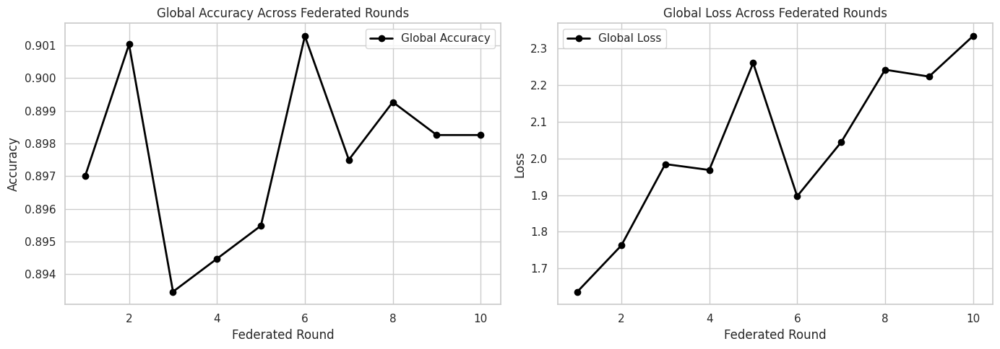

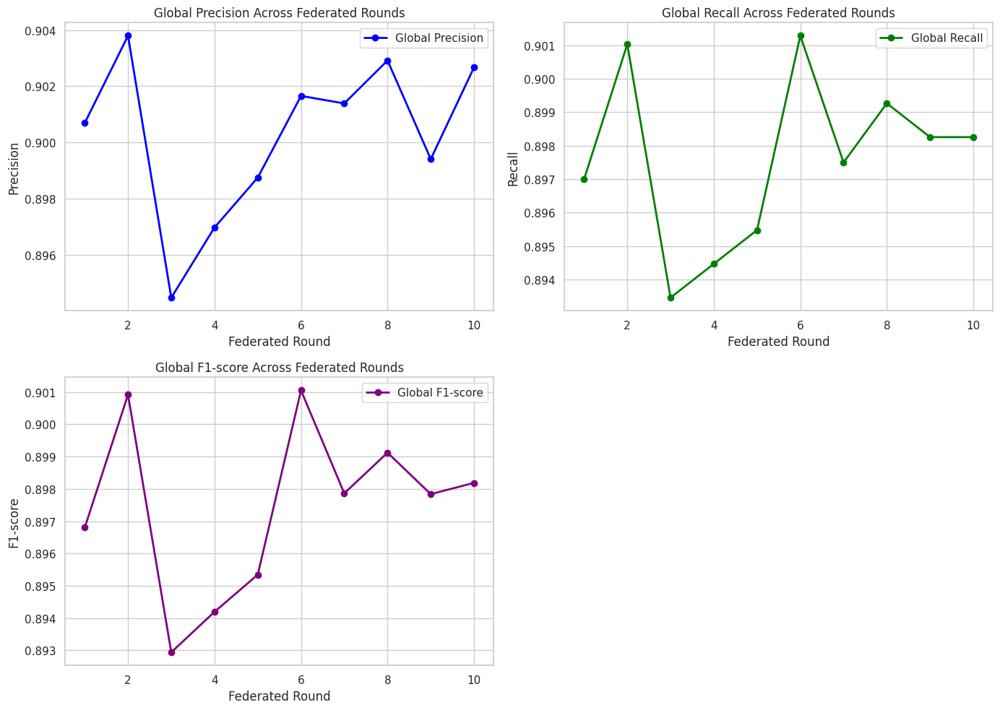

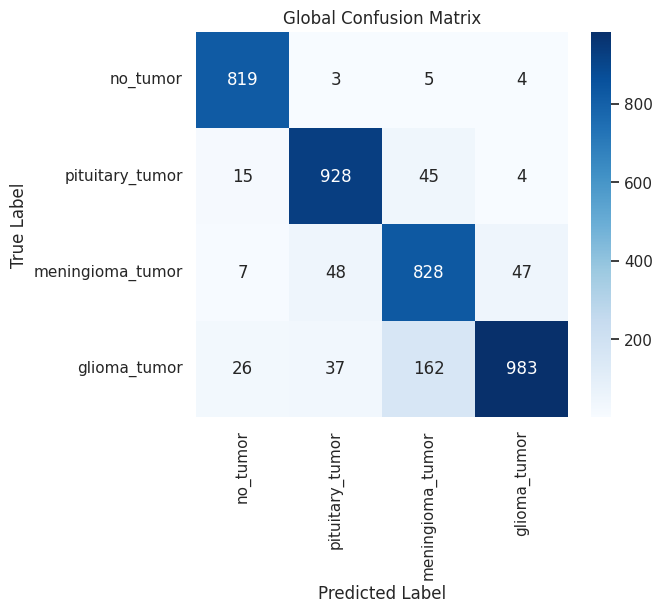

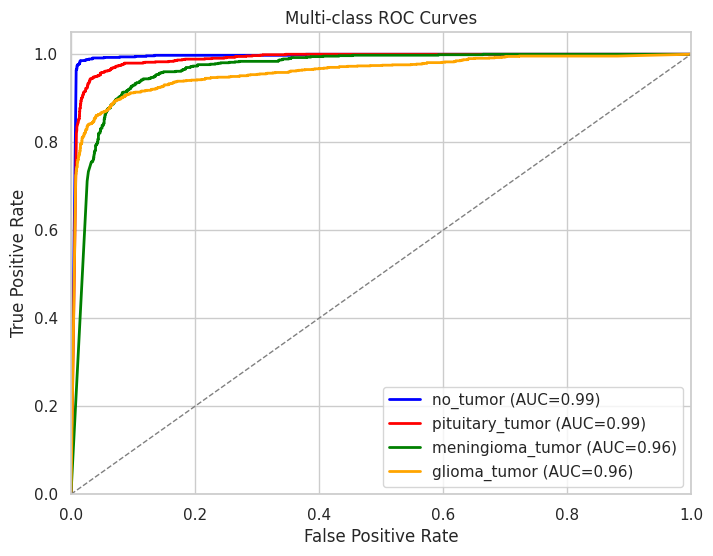

In [20]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.optimizers import Adam
from tqdm import tqdm
import keras
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize

keras.config.enable_unsafe_deserialization()

# ---------------- Parameters ----------------
NUM_CLIENTS = 10
NUM_ROUNDS = 10
batch_size = 8
epochs = 5
NUM_CLASSES = 4  # 4-class classification

# ---------------- Split data among clients ----------------
clients = []
for i in range(NUM_CLIENTS):
    client_data = train_paths[i * (len(train_paths) // NUM_CLIENTS):(i + 1) * (len(train_paths) // NUM_CLIENTS)]
    client_labels = train_labels[i * (len(train_labels) // NUM_CLIENTS):(i + 1) * (len(train_labels) // NUM_CLIENTS)]
    clients.append((client_data, client_labels))

# ---------------- Metrics storage ----------------
global_acc = []
global_loss = []
global_precision = []
global_recall = []
global_f1 = []
client_acc_history = {i: [] for i in range(NUM_CLIENTS)}
client_loss_history = {i: [] for i in range(NUM_CLIENTS)}

# ---------------- Federated learning loop ----------------
for round_num in range(NUM_ROUNDS):
    print(f"\n--- Federated Round {round_num+1} ---")
    
    # Select half clients randomly
    selected_client_indices = np.random.choice(len(clients), size=int(NUM_CLIENTS * 0.5), replace=False)
    
    for idx in range(NUM_CLIENTS):
        if idx in selected_client_indices:
            client = clients[idx]
            print(f"Training client {idx}...")
            
            client_model = tf.keras.models.clone_model(model)
            client_model.set_weights(model.get_weights())
            client_model.compile(
                optimizer=Adam(learning_rate=0.0001),
                loss='sparse_categorical_crossentropy',
                metrics=['sparse_categorical_accuracy']
            )
            
            steps_per_epoch = max(1, int(len(client[0]) / batch_size))
            history = client_model.fit(
                datagen(client[0], client[1], batch_size=batch_size, epochs=epochs),
                epochs=epochs,
                steps_per_epoch=steps_per_epoch,
                verbose=2
            )
            
            # Save client metrics
            client_acc_history[idx].append(np.mean(history.history['sparse_categorical_accuracy']))
            client_loss_history[idx].append(np.mean(history.history['loss']))
            
            # Aggregate weights with global model
            new_weights = []
            for layer_index in range(len(model.get_weights())):
                new_layer_weights = np.mean(
                    [client_model.get_weights()[layer_index], model.get_weights()[layer_index]], axis=0
                )
                new_weights.append(new_layer_weights)
            model.set_weights(new_weights)
        else:
            # Not selected → carry forward previous metrics
            if len(client_acc_history[idx]) > 0:
                client_acc_history[idx].append(client_acc_history[idx][-1])
                client_loss_history[idx].append(client_loss_history[idx][-1])
            else:
                client_acc_history[idx].append(np.nan)
                client_loss_history[idx].append(np.nan)

    # ---------------- Evaluate global model ----------------
    steps = int(len(test_paths)/batch_size)
    y_pred = []
    y_true = []
    y_pred_prob_list = []
    
    for x, y in tqdm(datagen(test_paths, test_labels, batch_size=batch_size, epochs=1), total=steps):
        pred_prob = model.predict(x, verbose=0)
        pred = np.argmax(pred_prob, axis=-1)
        y_pred.extend(pred)
        y_true.extend(y)
        y_pred_prob_list.append(pred_prob)
    
    y_pred_prob = np.vstack(y_pred_prob_list)
    
    # Metrics
    acc = np.mean(np.array(y_pred) == np.array(y_true))
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # AUC per class
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    auc_list = []
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
        auc_list.append(auc(fpr, tpr))
    
    # Global loss
    loss, _ = model.evaluate(datagen(test_paths, test_labels, batch_size=batch_size, epochs=1), steps=steps, verbose=0)
    
    # Append metrics
    global_acc.append(acc)
    global_precision.append(precision)
    global_recall.append(recall)
    global_f1.append(f1)
    global_loss.append(loss)
    
    print(f"Round {round_num+1} loss: {acc:.4f}\nMetrics: Acc={acc:.4f}, Prec={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, AUC={np.mean(auc_list):.4f}")

# ---------------- Plot Accuracy & Loss ----------------
sns.set(style="whitegrid")
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_ROUNDS+1), global_acc, marker='o', label='Global Accuracy', color='black', linewidth=2)
plt.xlabel('Federated Round')
plt.ylabel('Accuracy')
plt.title('Global Accuracy Across Federated Rounds')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_ROUNDS+1), global_loss, marker='o', label='Global Loss', color='black', linewidth=2)
plt.xlabel('Federated Round')
plt.ylabel('Loss')
plt.title('Global Loss Across Federated Rounds')
plt.legend()
plt.tight_layout()
plt.show()
# ---------------- Plot Additional Metrics ----------------
sns.set(style="whitegrid")
plt.figure(figsize=(14, 10))

# Precision
plt.subplot(2, 2, 1)
plt.plot(range(1, NUM_ROUNDS+1), global_precision, marker='o', color='blue', linewidth=2, label='Global Precision')
plt.xlabel('Federated Round')
plt.ylabel('Precision')
plt.title('Global Precision Across Federated Rounds')
plt.legend()

# Recall
plt.subplot(2, 2, 2)
plt.plot(range(1, NUM_ROUNDS+1), global_recall, marker='o', color='green', linewidth=2, label='Global Recall')
plt.xlabel('Federated Round')
plt.ylabel('Recall')
plt.title('Global Recall Across Federated Rounds')
plt.legend()

# F1-score
plt.subplot(2, 2, 3)
plt.plot(range(1, NUM_ROUNDS+1), global_f1, marker='o', color='purple', linewidth=2, label='Global F1-score')
plt.xlabel('Federated Round')
plt.ylabel('F1-score')
plt.title('Global F1-score Across Federated Rounds')
plt.legend()

plt.tight_layout()
plt.show()


# ---------------- Confusion Matrix ----------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Global Confusion Matrix')
plt.show()
# ---------------- Multi-class ROC Curves ----------------
plt.figure(figsize=(8,6))
colors = ['blue', 'red', 'green', 'orange']  # adjust if more classes

for i, cls_name in enumerate(unique_labels):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'{cls_name} (AUC={auc(fpr,tpr):.2f})')

plt.plot([0,1], [0,1], color='grey', lw=1, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves')
plt.legend(loc='lower right')
plt.show()


# ---------------- Save final global model ----------------
model.save('GLOBAL_model_MobileNet.hdf5')

In [21]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96       831
           1       0.91      0.94      0.92       992
           2       0.80      0.89      0.84       930
           3       0.95      0.81      0.88      1208

    accuracy                           0.90      3961
   macro avg       0.90      0.91      0.90      3961
weighted avg       0.90      0.90      0.90      3961



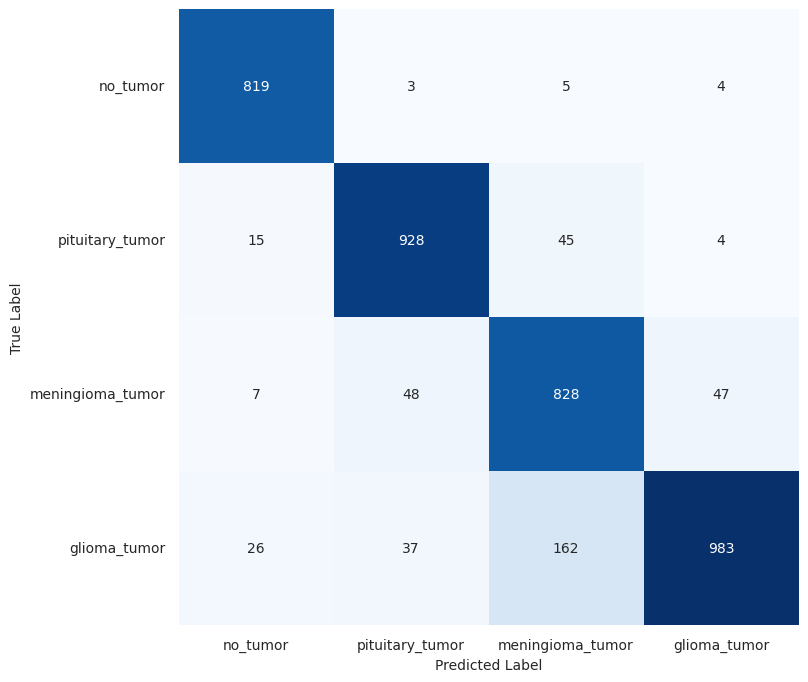

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_true, y_pred)

# Define the font size
font_size = 10

# Plot the confusion matrix
plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=unique_labels, yticklabels=unique_labels, annot_kws={"fontsize": font_size}, cbar=False)
plt.xlabel("Predicted Label", fontsize=font_size)
plt.ylabel("True Label", fontsize=font_size)
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size, rotation=0)
plt.show()

# Improved Code of Transfer Learning Based VGG-16 Model

In [23]:
#keras.utils.plot_model(model, show_shapes=True)

In [24]:
model.compile(optimizer=Adam(learning_rate=0.0001),
             loss='sparse_categorical_crossentropy',
             metrics=['sparse_categorical_accuracy'])

In [25]:
batch_size = 8
steps = int(len(train_paths)/batch_size)
epochs = 20
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps, verbose = 2)

Epoch 1/20
1740/1740 - 63s - 36ms/step - loss: 0.0262 - sparse_categorical_accuracy: 0.9955
Epoch 2/20
1740/1740 - 57s - 33ms/step - loss: 0.0160 - sparse_categorical_accuracy: 0.9959
Epoch 3/20
1740/1740 - 54s - 31ms/step - loss: 0.0140 - sparse_categorical_accuracy: 0.9969
Epoch 4/20
1740/1740 - 54s - 31ms/step - loss: 0.0153 - sparse_categorical_accuracy: 0.9963
Epoch 5/20
1740/1740 - 53s - 31ms/step - loss: 0.0141 - sparse_categorical_accuracy: 0.9963
Epoch 6/20
1740/1740 - 54s - 31ms/step - loss: 0.0175 - sparse_categorical_accuracy: 0.9960
Epoch 7/20
1740/1740 - 53s - 31ms/step - loss: 0.0127 - sparse_categorical_accuracy: 0.9968
Epoch 8/20
1740/1740 - 53s - 31ms/step - loss: 0.0107 - sparse_categorical_accuracy: 0.9963
Epoch 9/20
1740/1740 - 53s - 30ms/step - loss: 0.0153 - sparse_categorical_accuracy: 0.9957
Epoch 10/20
1740/1740 - 53s - 31ms/step - loss: 0.0112 - sparse_categorical_accuracy: 0.9973
Epoch 11/20
1740/1740 - 54s - 31ms/step - loss: 0.0130 - sparse_categorical_acc

496it [01:05,  7.60it/s]


Precision: 0.8962
Recall: 0.8947
F1-score: 0.8944
Accuracy: 0.8947


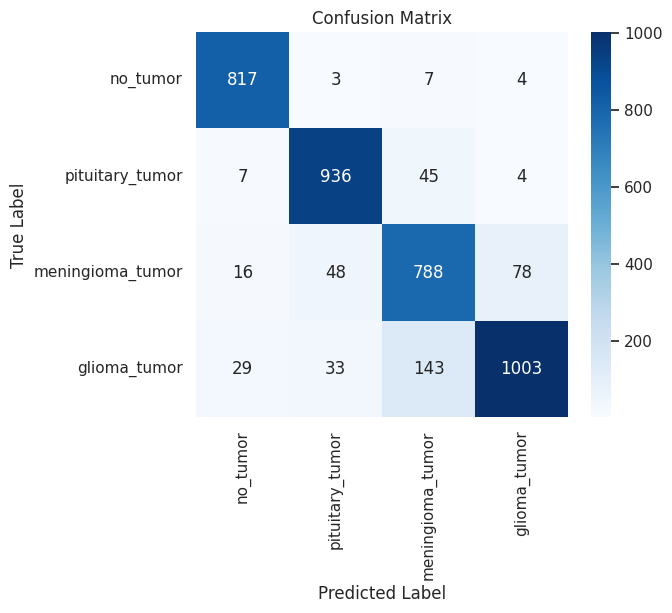

1/1 - 0s - 39ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 40ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 39ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 39ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 39ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 39ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 39ms/step
1/1 - 0s - 40ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 40ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 39ms/step
1/1 - 0s - 38ms/step
1/1 - 0s - 37ms/step
1/1 - 0s - 38

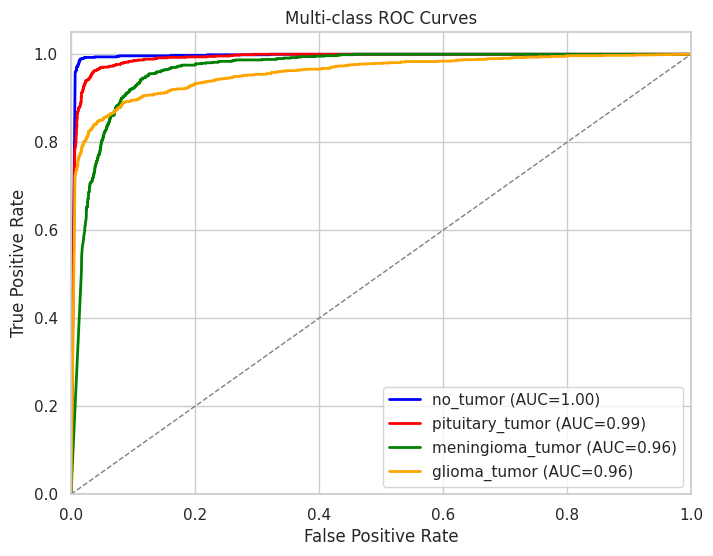

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------- Evaluation ----------------
batch_size = 8
steps = int(len(test_paths)/batch_size)
y_pred = []
y_true = []

for x, y in tqdm(datagen(test_paths, test_labels, batch_size=batch_size, epochs=1), total=steps):
    pred_prob = model.predict(x, verbose=0)  # keep probabilities for ROC
    pred = np.argmax(pred_prob, axis=-1)
    
    y_pred.extend(pred)
    y_true.extend(y)

# ---------------- Metrics ----------------
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
acc = np.mean(np.array(y_pred) == np.array(y_true))  # ✅ accuracy line

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Accuracy: {acc:.4f}")  # ✅ print accuracy

# ---------------- Confusion Matrix ----------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# ---------------- ROC Curves ----------------
# Convert to one-hot for ROC
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

# If you need probabilities for each batch, stack them
# Assuming pred_prob from last batch for simplicity; better: collect all batch probabilities
# Here we recompute them on test set:
y_pred_prob = []
for x, _ in datagen(test_paths, test_labels, batch_size=batch_size, epochs=1):
    prob = model.predict(x, verbose=2)
    y_pred_prob.append(prob)
y_pred_prob = np.vstack(y_pred_prob)

plt.figure(figsize=(8,6))
colors = ['blue', 'red', 'green', 'orange']  # extend if more classes
for i, cls_name in enumerate(unique_labels):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'{cls_name} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], color='grey', lw=1, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves')
plt.legend(loc='lower right')
plt.show()


In [27]:
# batch_size = 8
# steps = int(len(test_paths)/batch_size)
# y_pred = []
# y_true = []
# for x,y in tqdm(datagen(test_paths, test_labels, batch_size=batch_size, epochs=1), total=steps):
#     pred = model.predict(x)
#     pred = np.argmax(pred, axis=-1)
#     for i in decode_label(pred):
#         y_pred.append(i)
#     for i in decode_label(y):
#         y_true.append(i)

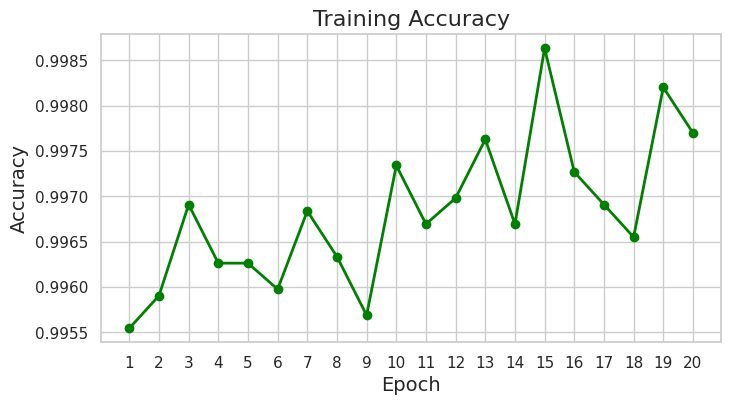

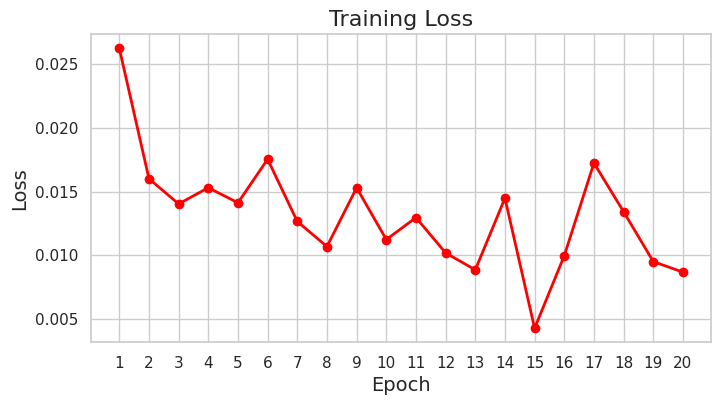

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
epochs_range = range(1, epochs+1)

# ---------------- Plot Accuracy ----------------
plt.figure(figsize=(8,4))
plt.plot(epochs_range, history.history['sparse_categorical_accuracy'], marker='o', color='green', linewidth=2)
plt.title('Training Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(epochs_range)
plt.grid(True)
plt.show()

# ---------------- Plot Loss ----------------
plt.figure(figsize=(8,4))
plt.plot(epochs_range, history.history['loss'], marker='o', color='red', linewidth=2)
plt.title('Training Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.xticks(epochs_range)
plt.grid(True)
plt.show()


In [29]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       831
           1       0.92      0.94      0.93       992
           2       0.80      0.85      0.82       930
           3       0.92      0.83      0.87      1208

    accuracy                           0.89      3961
   macro avg       0.90      0.90      0.90      3961
weighted avg       0.90      0.89      0.89      3961



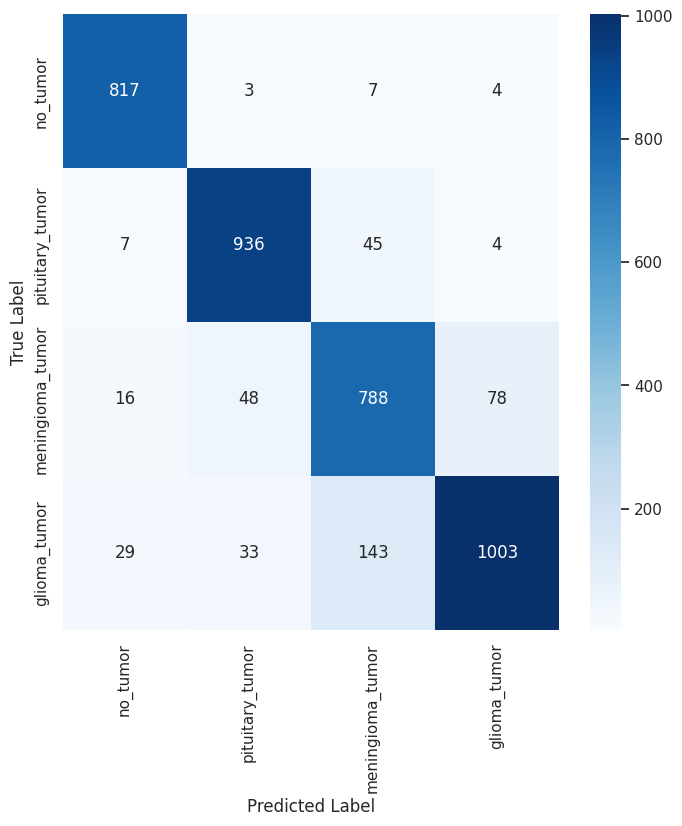

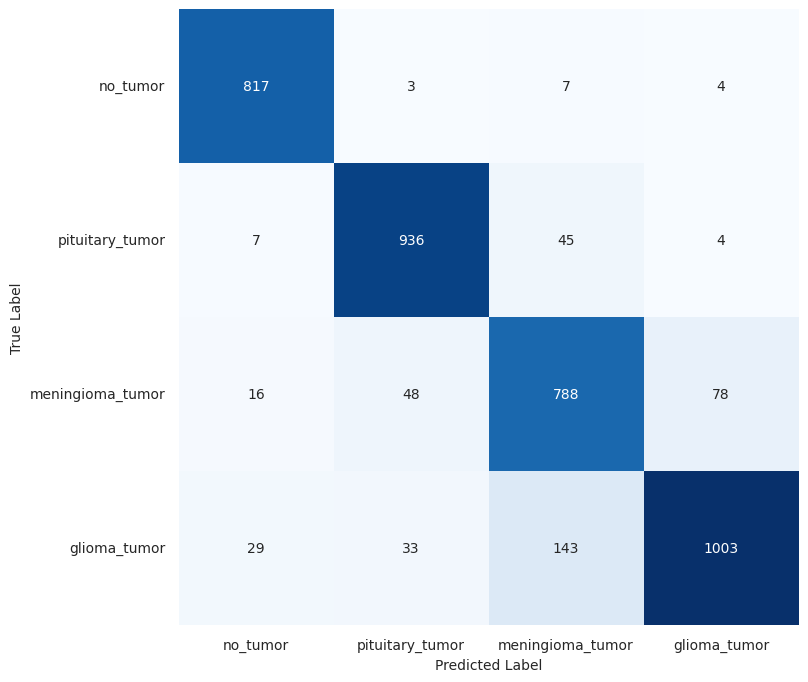

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Get the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Get the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Define the font size
font_size = 10

# Plot the confusion matrix
plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=unique_labels, yticklabels=unique_labels, annot_kws={"fontsize": font_size}, cbar=False)
plt.xlabel("Predicted Label", fontsize=font_size)
plt.ylabel("True Label", fontsize=font_size)
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size, rotation=0)
plt.show()

✅ Fixed class-to-index mapping:
  no_tumor: 0
  pituitary_tumor: 1
  meningioma_tumor: 2
  glioma_tumor: 3

📌 Selected image paths:
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/no_tumor/NoTumor_test_2297.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/Glioma_test_257.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/Glioma_test_1917.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/pituitary_tumor/Pituitary_test_1894.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/pituitary_tumor/Pituitary_test_2806.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/meningioma_tumor/Meningioma_test_2387.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/Glioma_test_559.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/meningioma_tumor/Meningioma_test_1534.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/no_tumor/NoTumor_test_2494.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/

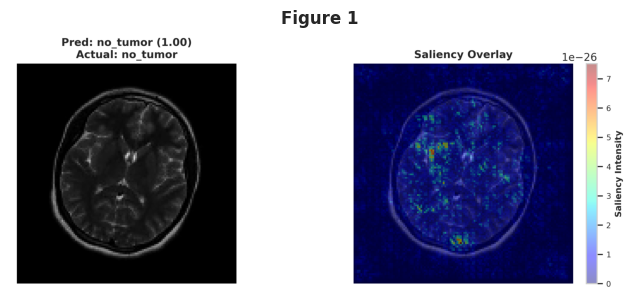

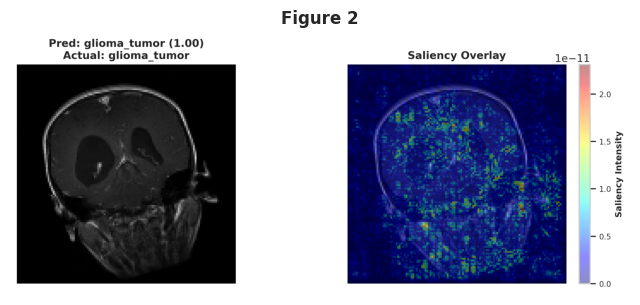

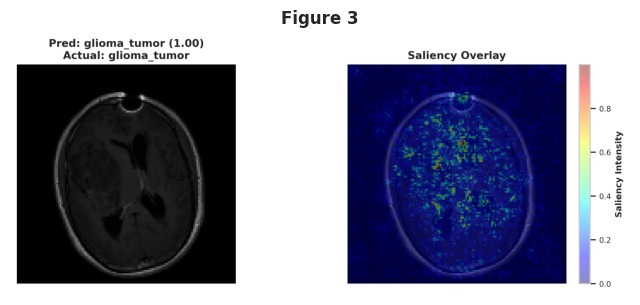

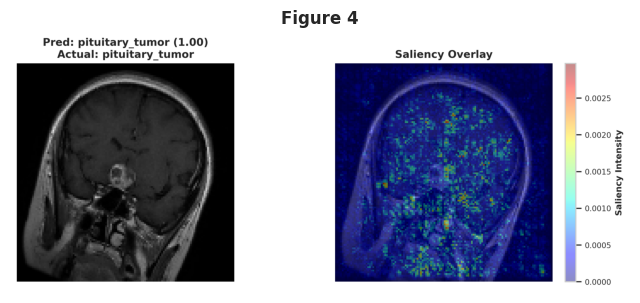

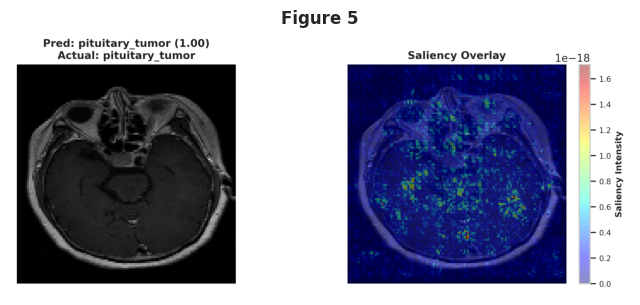

...

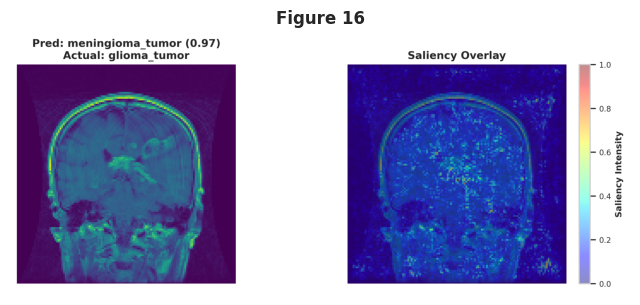

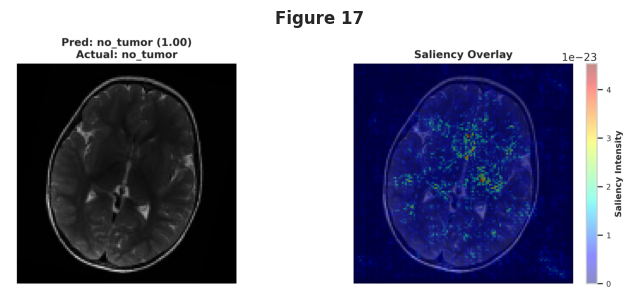

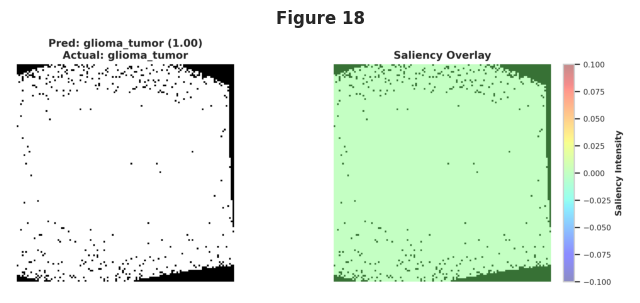

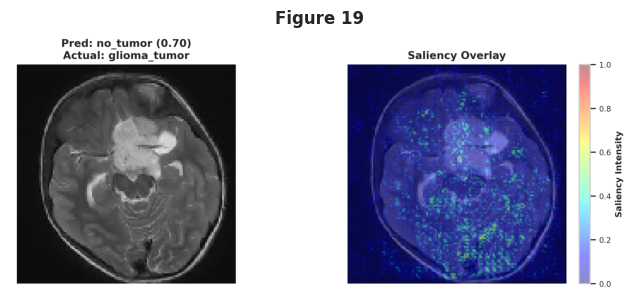

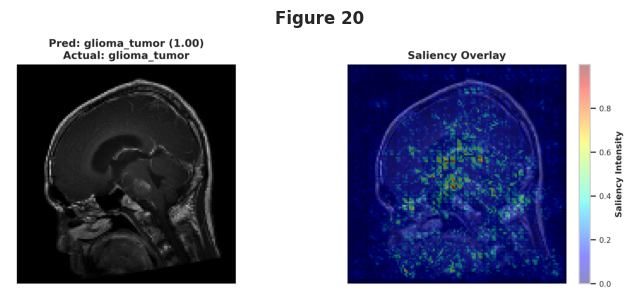

In [31]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os, random
import matplotlib.image as mpimg

# -----------------------------------
# Paths
# -----------------------------------
train_dir = '/kaggle/input/elite-lab-dataset/tumordata/Training/'
test_dir = '/kaggle/input/elite-lab-dataset/tumordata/Testing/'

# -----------------------------------
# Fixed Label Order
# -----------------------------------
fixed_label_order = ["no_tumor", "pituitary_tumor", "meningioma_tumor", "glioma_tumor"]
class_to_idx = {label: idx for idx, label in enumerate(fixed_label_order)}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}

display_labels = fixed_label_order  # for printing & plotting
print("✅ Fixed class-to-index mapping:")
for k, v in class_to_idx.items():
    print(f"  {k}: {v}")

# -----------------------------------
# Helper Functions
# -----------------------------------
def preprocess_image(img_path, target_size=(128,128)):
    """Load and preprocess image"""
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array / 255.0

def get_actual_label(img_path):
    """Extract folder name and map to display label"""
    folder_name = os.path.basename(os.path.dirname(img_path))
    return folder_name if folder_name in display_labels else "Unknown"

def get_random_test_images(test_dir, n=6):
    """Select n random images from test directory"""
    all_image_paths = []
    for folder_name in fixed_label_order:
        folder_path = os.path.join(test_dir, folder_name)
        if os.path.exists(folder_path):
            images_in_folder = [
                os.path.join(folder_path, f)
                for f in os.listdir(folder_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]
            all_image_paths.extend(images_in_folder)
    selected = random.sample(all_image_paths, min(n, len(all_image_paths)))
    print("\n📌 Selected image paths:")
    for p in selected:
        print("   -", p)
    return selected

# -----------------------------------
# Saliency Plotting Function
# -----------------------------------
def plot_saliency_with_full_probs(model, img_paths, save_dir="saliency_outputs"):
    os.makedirs(save_dir, exist_ok=True)

    for idx, img_path in enumerate(img_paths):
        print(f"\n🖼 Processing image {idx+1}/{len(img_paths)}: {img_path}")

        # Preprocess
        img_array = preprocess_image(img_path)
        actual_label = get_actual_label(img_path)

        # Prediction
        preds = model.predict(img_array, verbose=0)[0]

        # Print all class probabilities in fixed order
        print("🔹 Class probabilities:")
        for cls_name, prob in zip(display_labels, preds):
            print(f"   {cls_name}: {prob:.4f}")

        pred_idx = np.argmax(preds)
        pred_label = display_labels[pred_idx]
        pred_prob = preds[pred_idx]

        # Saliency computation
        img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
        with tf.GradientTape() as tape:
            tape.watch(img_tensor)
            class_output = model(img_tensor)[0, pred_idx]
        grads = tape.gradient(class_output, img_tensor)[0].numpy()
        saliency = np.max(np.abs(grads), axis=-1)

        # Normalize saliency
        saliency -= saliency.min()
        saliency /= (saliency.max() + 1e-8)

        # Original image
        orig_img = image.load_img(img_path, target_size=(128,128))

        # Plot figure (1 row × 2 columns)
        fig, axes = plt.subplots(1, 2, figsize=(10,4))

        # Left: Original Image
        axes[0].imshow(orig_img)
        axes[0].axis('off')
        axes[0].set_title(
            f"Pred: {pred_label} ({pred_prob:.2f})\nActual: {actual_label}",
            fontsize=11, fontweight='bold'
        )

        # Right: Saliency Overlay
        axes[1].imshow(orig_img)
        sal = axes[1].imshow(saliency, cmap='jet', alpha=0.45)
        axes[1].axis('off')
        axes[1].set_title("Saliency Overlay", fontsize=11, fontweight='bold')

        # Colorbar
        cbar = fig.colorbar(sal, ax=axes[1], fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label('Saliency Intensity', fontsize=9, fontweight='bold')

        plt.tight_layout()

        # Save figure
        save_path = os.path.join(save_dir, f"saliency_{idx+1}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close(fig)

        print(f"✅ Saved: {save_path}")
        print(f"🔸 Prediction: {pred_label} ({pred_prob:.4f}) | Actual: {actual_label}")

    # Display all saved figures inline
    print("\n📌 Displaying saved figures inline:")
    for idx in range(len(img_paths)):
        img_file = os.path.join(save_dir, f"saliency_{idx+1}.png")
        img = mpimg.imread(img_file)
        plt.figure(figsize=(8,4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Figure {idx+1}", fontsize=12, fontweight='bold')
        plt.show()

# -----------------------------------
# Usage Example
# -----------------------------------
img_paths = get_random_test_images(test_dir, n=20)
plot_saliency_with_full_probs(model, img_paths)

✅ Fixed class-to-index mapping:
  no_tumor: 0
  pituitary_tumor: 1
  meningioma_tumor: 2
  glioma_tumor: 3

📌 Selected image paths:
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/Glioma_test_580.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/pituitary_tumor/Pituitary_test_131.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/pituitary_tumor/Pituitary_test_1102.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/meningioma_tumor/Meningioma_test_458.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/meningioma_tumor/Meningioma_test_2158.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/pituitary_tumor/Pituitary_test_497.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/Glioma_test_1604.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/meningioma_tumor/Meningioma_test_1279.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/2747.png
   - /kaggle/input/elite-lab-dataset/tumo

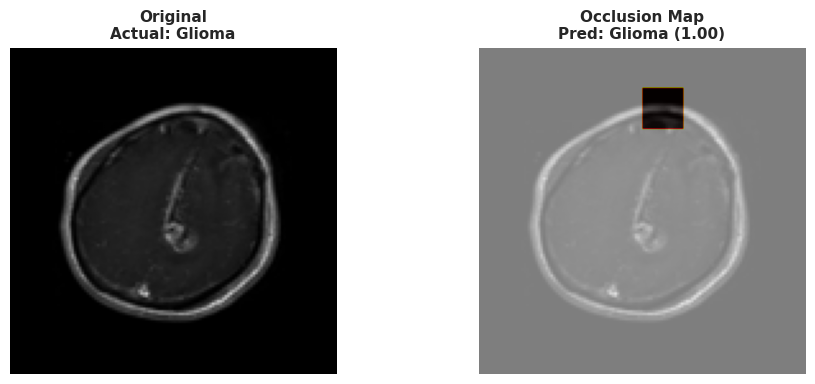

✅ Saved: occlusion_outputs/occlusion_1.png

🖼 Processing image 2/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/pituitary_tumor/Pituitary_test_131.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 0.1345
   Meningioma: 0.0000
   Glioma: 0.8655
🔸 Prediction: Glioma (0.8655) | Actual: Pituitary Tumor


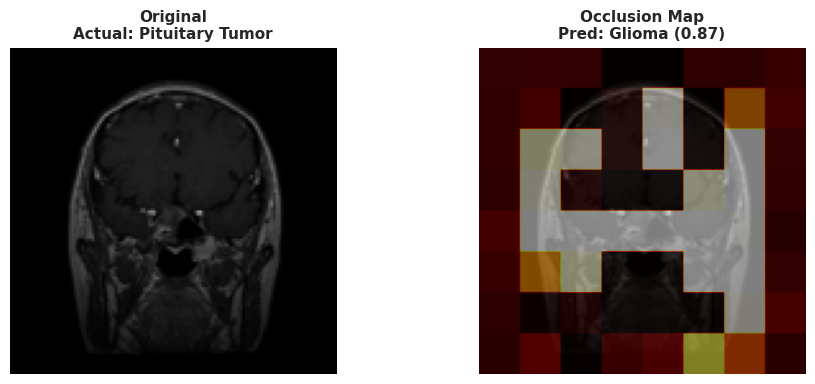

✅ Saved: occlusion_outputs/occlusion_2.png

🖼 Processing image 3/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/pituitary_tumor/Pituitary_test_1102.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 1.0000
   Meningioma: 0.0000
   Glioma: 0.0000
🔸 Prediction: Pituitary Tumor (1.0000) | Actual: Pituitary Tumor


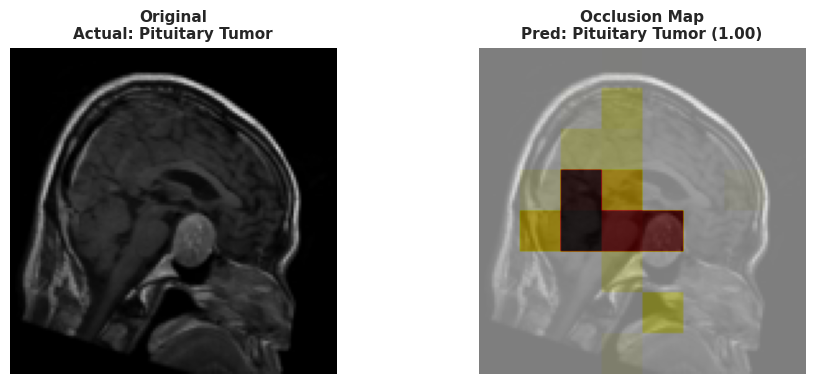

✅ Saved: occlusion_outputs/occlusion_3.png

🖼 Processing image 4/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/meningioma_tumor/Meningioma_test_458.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 0.0000
   Meningioma: 1.0000
   Glioma: 0.0000
🔸 Prediction: Meningioma (1.0000) | Actual: Meningioma


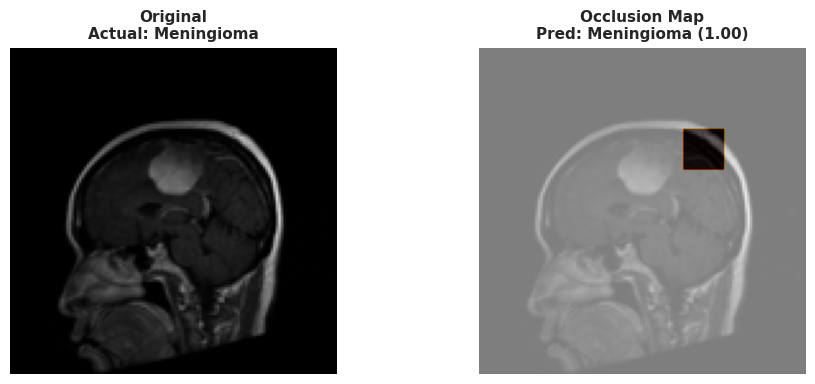

✅ Saved: occlusion_outputs/occlusion_4.png

🖼 Processing image 5/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/meningioma_tumor/Meningioma_test_2158.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 0.0000
   Meningioma: 0.9868
   Glioma: 0.0132
🔸 Prediction: Meningioma (0.9868) | Actual: Meningioma


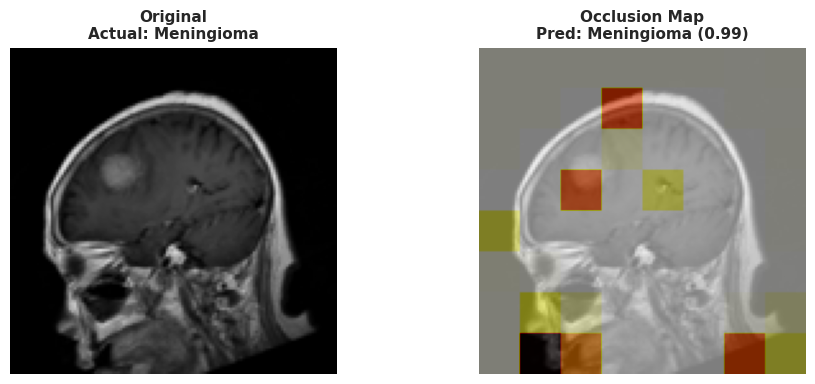

✅ Saved: occlusion_outputs/occlusion_5.png

🖼 Processing image 6/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/pituitary_tumor/Pituitary_test_497.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 1.0000
   Meningioma: 0.0000
   Glioma: 0.0000
🔸 Prediction: Pituitary Tumor (1.0000) | Actual: Pituitary Tumor


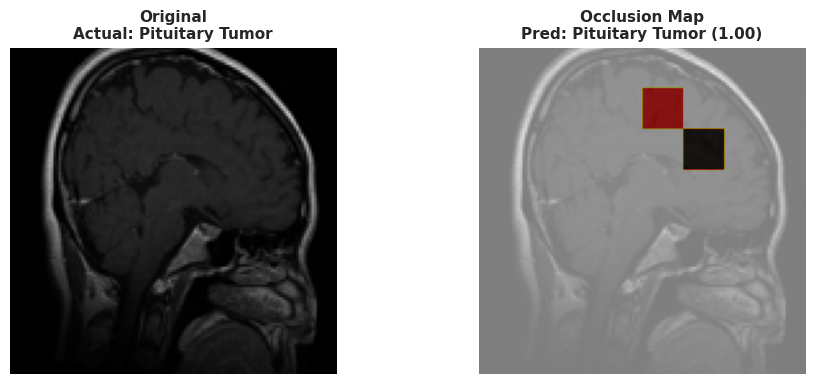

✅ Saved: occlusion_outputs/occlusion_6.png

🖼 Processing image 7/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/Glioma_test_1604.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 0.0000
   Meningioma: 0.0000
   Glioma: 1.0000
🔸 Prediction: Glioma (1.0000) | Actual: Glioma


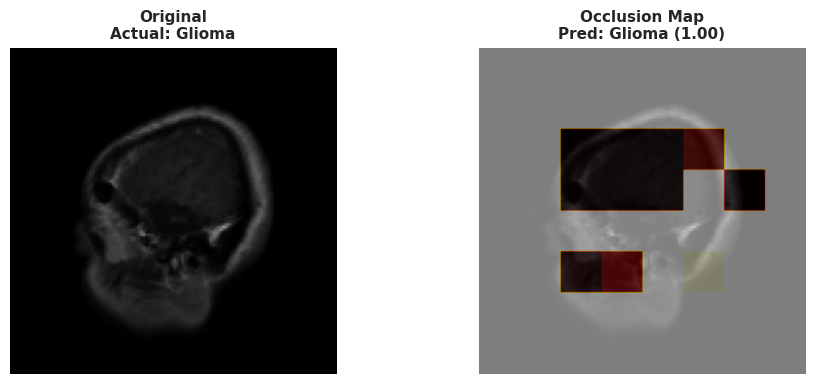

✅ Saved: occlusion_outputs/occlusion_7.png

🖼 Processing image 8/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/meningioma_tumor/Meningioma_test_1279.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 0.0000
   Meningioma: 1.0000
   Glioma: 0.0000
🔸 Prediction: Meningioma (1.0000) | Actual: Meningioma


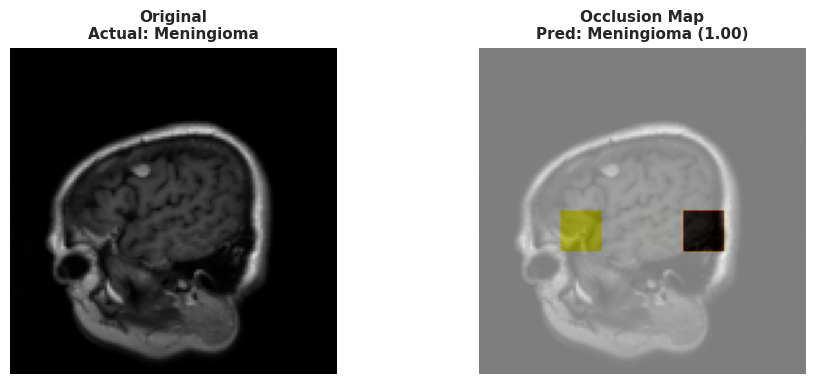

✅ Saved: occlusion_outputs/occlusion_8.png

🖼 Processing image 9/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/2747.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 0.0000
   Meningioma: 0.0000
   Glioma: 1.0000
🔸 Prediction: Glioma (1.0000) | Actual: Glioma


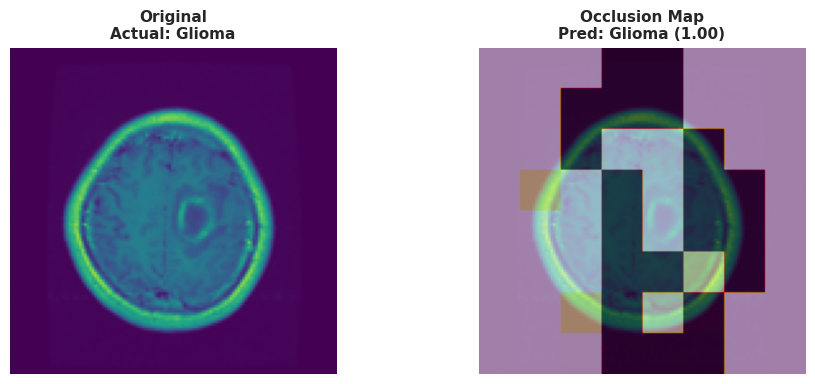

✅ Saved: occlusion_outputs/occlusion_9.png

🖼 Processing image 10/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/HR_img (816).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 0.0000
   Meningioma: 0.0000
   Glioma: 1.0000
🔸 Prediction: Glioma (1.0000) | Actual: Glioma


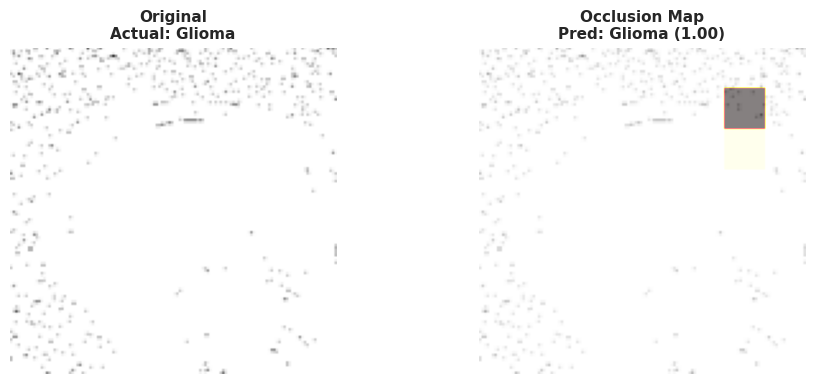

✅ Saved: occlusion_outputs/occlusion_10.png

🖼 Processing image 11/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/pituitary_tumor/2232.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 0.9858
   Meningioma: 0.0142
   Glioma: 0.0000
🔸 Prediction: Pituitary Tumor (0.9858) | Actual: Pituitary Tumor


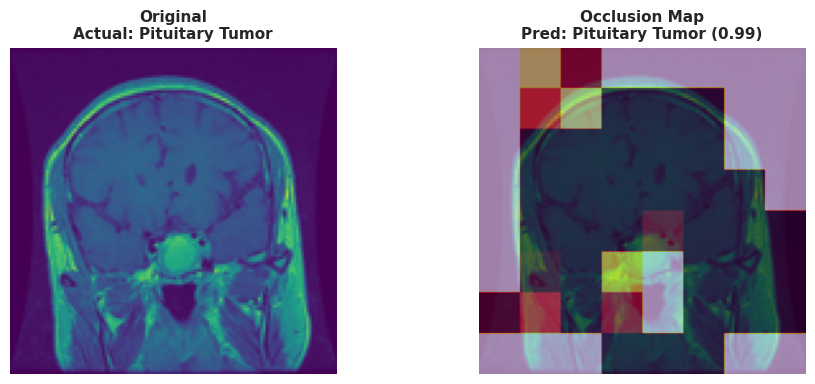

✅ Saved: occlusion_outputs/occlusion_11.png

🖼 Processing image 12/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/pituitary_tumor/Pituitary_test_2822.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 1.0000
   Meningioma: 0.0000
   Glioma: 0.0000
🔸 Prediction: Pituitary Tumor (1.0000) | Actual: Pituitary Tumor


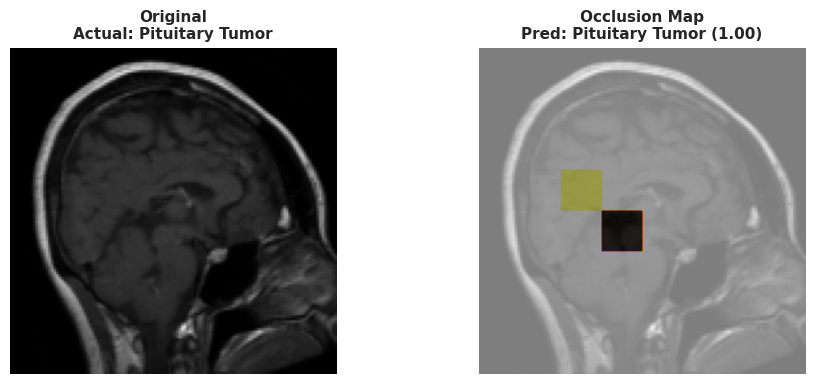

✅ Saved: occlusion_outputs/occlusion_12.png

🖼 Processing image 13/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/HR_img (1025).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 0.0000
   Meningioma: 0.0000
   Glioma: 1.0000
🔸 Prediction: Glioma (1.0000) | Actual: Glioma


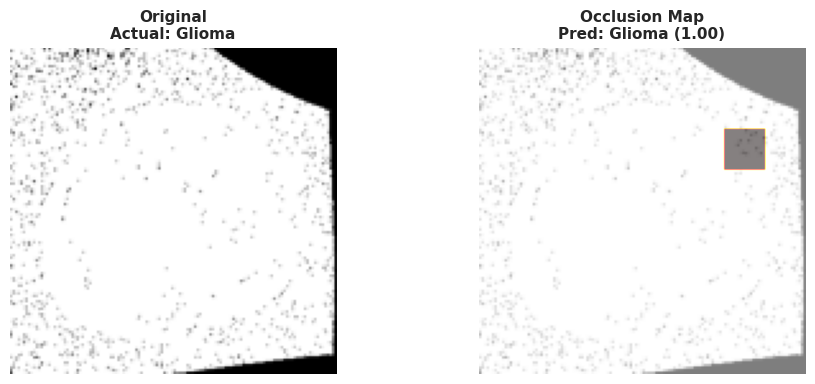

✅ Saved: occlusion_outputs/occlusion_13.png

🖼 Processing image 14/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/pituitary_tumor/Pituitary_test_2547.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 1.0000
   Meningioma: 0.0000
   Glioma: 0.0000
🔸 Prediction: Pituitary Tumor (1.0000) | Actual: Pituitary Tumor


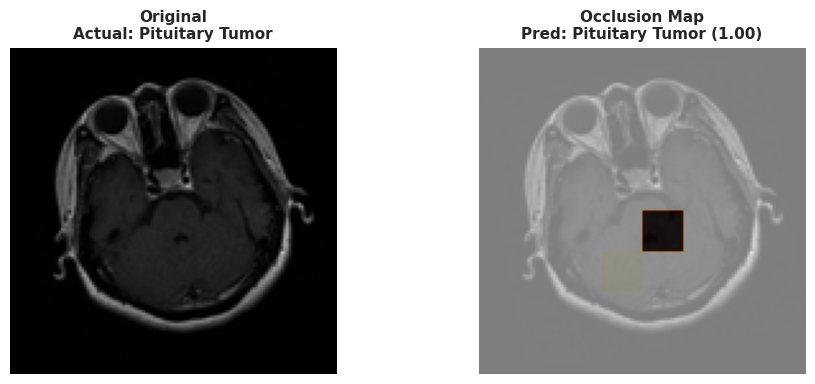

✅ Saved: occlusion_outputs/occlusion_14.png

🖼 Processing image 15/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/image(23).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
🔹 Class probabilities:
   No Tumor: 1.0000
   Pituitary Tumor: 0.0000
   Meningioma: 0.0000
   Glioma: 0.0000
🔸 Prediction: No Tumor (1.0000) | Actual: Glioma


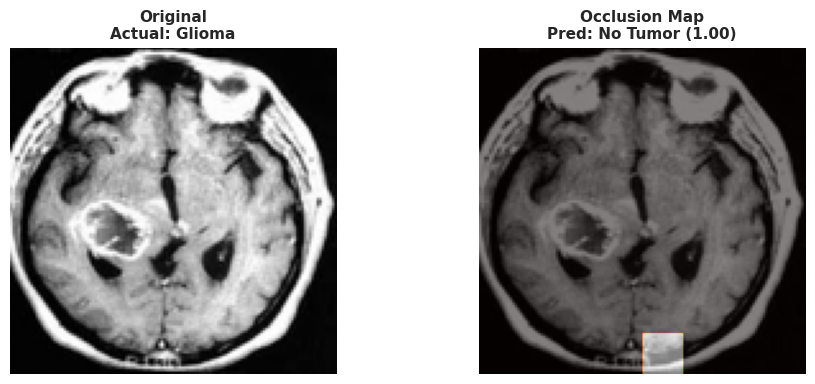

✅ Saved: occlusion_outputs/occlusion_15.png

🖼 Processing image 16/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/meningioma_tumor/3054.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 0.0000
   Meningioma: 1.0000
   Glioma: 0.0000
🔸 Prediction: Meningioma (1.0000) | Actual: Meningioma


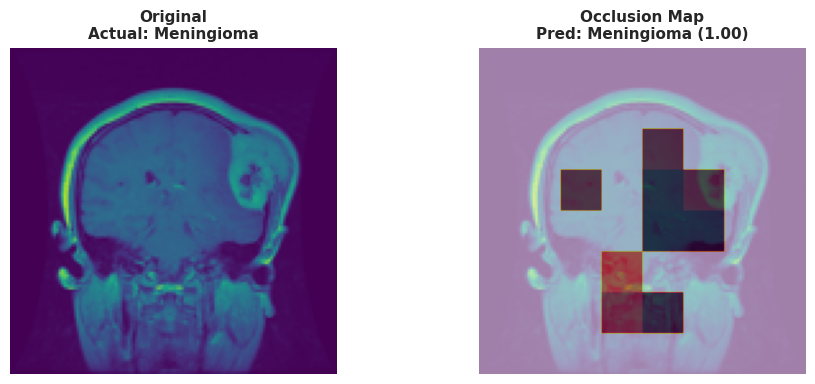

✅ Saved: occlusion_outputs/occlusion_16.png

🖼 Processing image 17/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/no_tumor/image(31).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
🔹 Class probabilities:
   No Tumor: 1.0000
   Pituitary Tumor: 0.0000
   Meningioma: 0.0000
   Glioma: 0.0000
🔸 Prediction: No Tumor (1.0000) | Actual: No Tumor


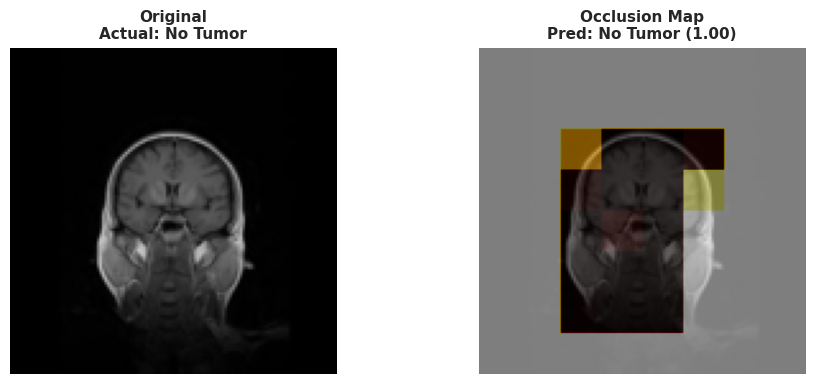

✅ Saved: occlusion_outputs/occlusion_17.png

🖼 Processing image 18/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/image(3).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 0.0000
   Meningioma: 0.0080
   Glioma: 0.9920
🔸 Prediction: Glioma (0.9920) | Actual: Glioma


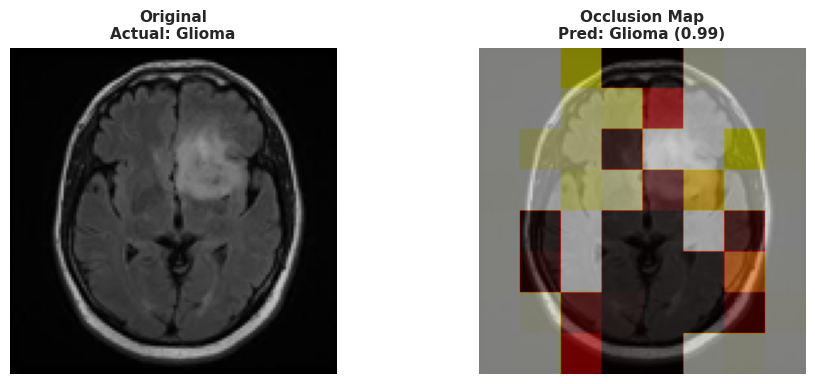

✅ Saved: occlusion_outputs/occlusion_18.png

🖼 Processing image 19/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/meningioma_tumor/Meningioma_test_978.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 0.0000
   Meningioma: 1.0000
   Glioma: 0.0000
🔸 Prediction: Meningioma (1.0000) | Actual: Meningioma


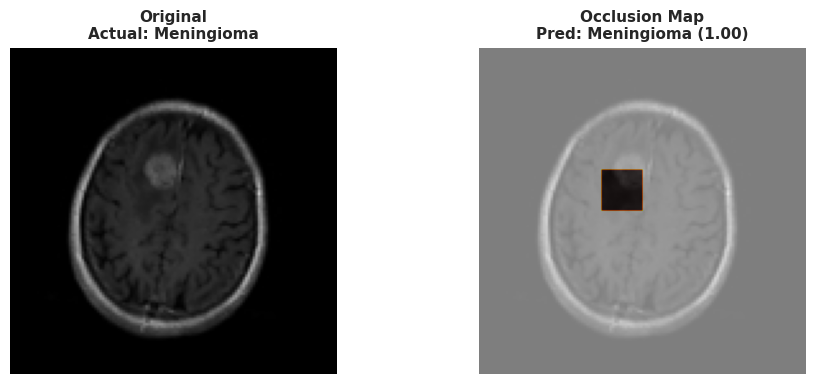

✅ Saved: occlusion_outputs/occlusion_19.png

🖼 Processing image 20/20: /kaggle/input/elite-lab-dataset/tumordata/Testing/pituitary_tumor/2151.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
🔹 Class probabilities:
   No Tumor: 0.0000
   Pituitary Tumor: 1.0000
   Meningioma: 0.0000
   Glioma: 0.0000
🔸 Prediction: Pituitary Tumor (1.0000) | Actual: Pituitary Tumor


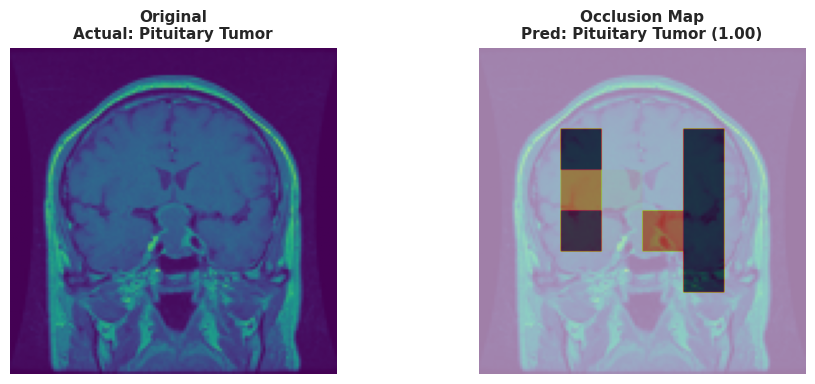

✅ Saved: occlusion_outputs/occlusion_20.png


In [32]:
import os
import random
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
train_dir = '/kaggle/input/elite-lab-dataset/tumordata/Training/'
test_dir = '/kaggle/input/elite-lab-dataset/tumordata/Testing/'

# -----------------------------
# Fixed Label Order
# -----------------------------
fixed_label_order = ["no_tumor", "pituitary_tumor", "meningioma_tumor", "glioma_tumor"]
class_to_idx = {label: idx for idx, label in enumerate(fixed_label_order)}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}

# Human-readable labels
label_map = {
    'no_tumor': 'No Tumor',
    'pituitary_tumor': 'Pituitary Tumor',
    'meningioma_tumor': 'Meningioma',
    'glioma_tumor': 'Glioma'
}

print("✅ Fixed class-to-index mapping:")
for k, v in class_to_idx.items():
    print(f"  {k}: {v}")

# -----------------------------
# Helper Functions
# -----------------------------
def preprocess_image(img_path, target_size=(128,128)):
    img = Image.open(img_path).convert("RGB")
    img = img.resize(target_size)
    img_array = np.array(img)/255.0
    return img_array

def get_actual_label(img_path):
    folder_name = os.path.basename(os.path.dirname(img_path))
    return label_map.get(folder_name, folder_name)

def get_random_test_images(test_dir, n=6):
    all_image_paths = []
    for folder_name in fixed_label_order:
        folder_path = os.path.join(test_dir, folder_name)
        if os.path.exists(folder_path):
            images_in_folder = [
                os.path.join(folder_path, f)
                for f in os.listdir(folder_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]
            all_image_paths.extend(images_in_folder)
    selected = random.sample(all_image_paths, min(n, len(all_image_paths)))
    print("\n📌 Selected image paths:")
    for p in selected:
        print("   -", p)
    return selected

# -----------------------------
# Occlusion Map Function
# -----------------------------
def occlusion_matrix(model, img, actual_class_idx=None, patch_size=32):
    h, w, c = img.shape
    occlusion_map = np.zeros((h, w))

    for i in range(0, h, patch_size):
        for j in range(0, w, patch_size):
            img_copy = img.copy()
            img_copy[i:i+patch_size, j:j+patch_size] = 0
            img_copy_batch = np.expand_dims(img_copy, axis=0)
            preds = model.predict(img_copy_batch, verbose=0)
            prob = preds[0, actual_class_idx] if actual_class_idx is not None else np.max(preds)
            occlusion_map[i:i+patch_size, j:j+patch_size] = prob
    return occlusion_map

# -----------------------------
# Plot Function
# -----------------------------
def plot_occlusion_maps(model, img_paths, patch_size=32, save_dir="occlusion_outputs"):
    os.makedirs(save_dir, exist_ok=True)

    for idx, img_path in enumerate(img_paths):
        print(f"\n🖼 Processing image {idx+1}/{len(img_paths)}: {img_path}")
        img = preprocess_image(img_path)
        actual_label = get_actual_label(img_path)

        # Prediction
        preds = model.predict(np.expand_dims(img,0))[0]
        pred_idx = np.argmax(preds)
        pred_label = label_map[fixed_label_order[pred_idx]]
        pred_prob = preds[pred_idx]

        # Print all class probabilities in fixed order
        print("🔹 Class probabilities:")
        for i, cls_name in enumerate(fixed_label_order):
            cls_label = label_map[cls_name]
            print(f"   {cls_label}: {preds[i]:.4f}")
        print(f"🔸 Prediction: {pred_label} ({pred_prob:.4f}) | Actual: {actual_label}")

        # Occlusion Map
        actual_class_idx = class_to_idx[os.path.basename(os.path.dirname(img_path))]
        occ_map = occlusion_matrix(model, img, actual_class_idx=actual_class_idx, patch_size=patch_size)
        occ_map_norm = (occ_map - np.min(occ_map)) / (np.max(occ_map)-np.min(occ_map)+1e-8)

        # Plot
        fig, axes = plt.subplots(1,2, figsize=(10,4))
        axes[0].imshow(img)
        axes[0].axis('off')
        axes[0].set_title(f"Original\nActual: {actual_label}", fontsize=11, fontweight='bold')

        axes[1].imshow(img)
        axes[1].imshow(occ_map_norm, cmap='hot', alpha=0.5)
        axes[1].axis('off')
        axes[1].set_title(f"Occlusion Map\nPred: {pred_label} ({pred_prob:.2f})", fontsize=11, fontweight='bold')

        plt.tight_layout()
        save_path = os.path.join(save_dir, f"occlusion_{idx+1}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved: {save_path}")

# -----------------------------
# Usage Example
# -----------------------------
img_paths = get_random_test_images(test_dir, n=20)
plot_occlusion_maps(model, img_paths, patch_size=16)

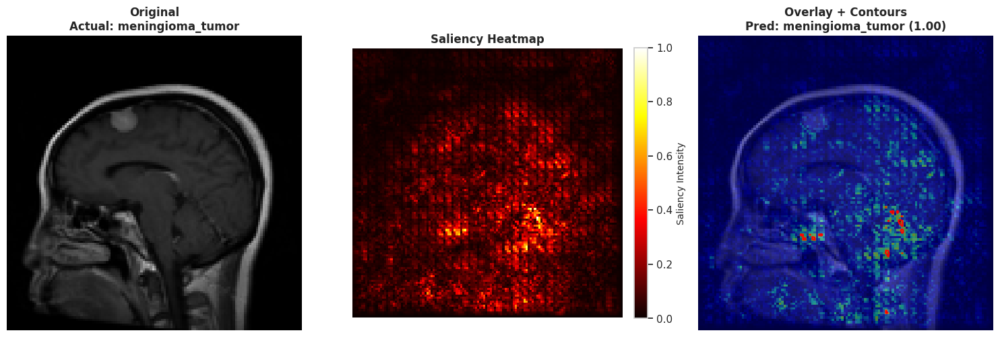

✅ Saved: saliency_contours/saliency_1.png | Prediction: meningioma_tumor (0.9999) | Actual: meningioma_tumor


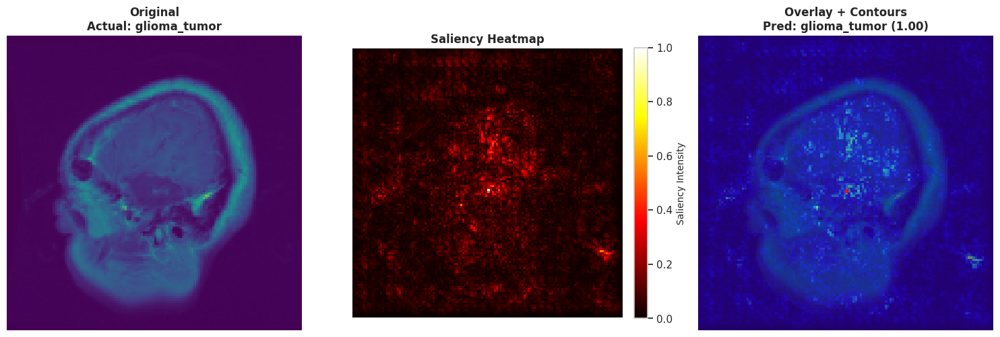

✅ Saved: saliency_contours/saliency_2.png | Prediction: glioma_tumor (1.0000) | Actual: glioma_tumor


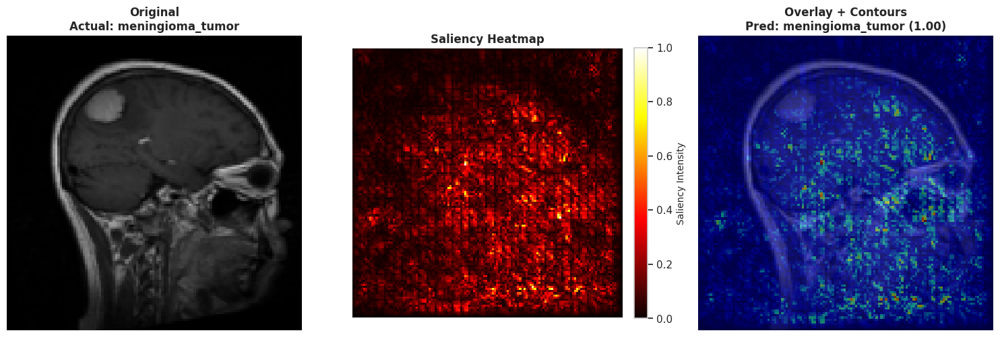

✅ Saved: saliency_contours/saliency_3.png | Prediction: meningioma_tumor (1.0000) | Actual: meningioma_tumor


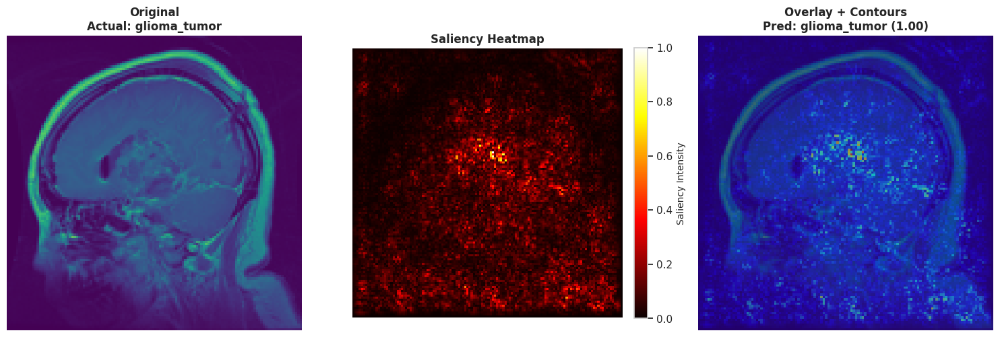

✅ Saved: saliency_contours/saliency_4.png | Prediction: glioma_tumor (1.0000) | Actual: glioma_tumor


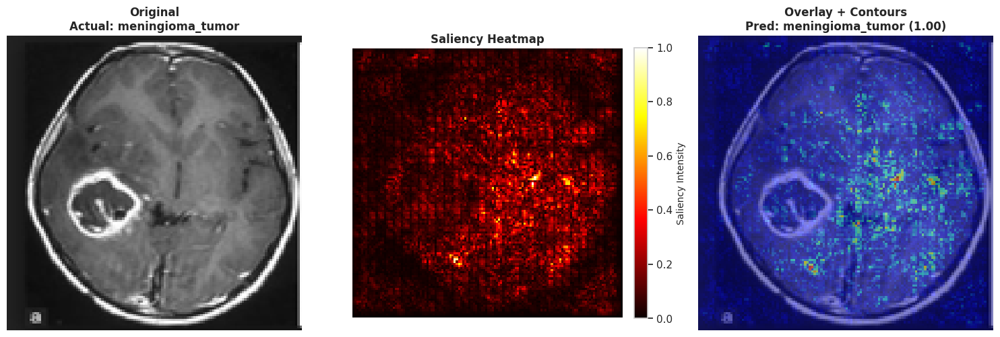

✅ Saved: saliency_contours/saliency_5.png | Prediction: meningioma_tumor (1.0000) | Actual: meningioma_tumor


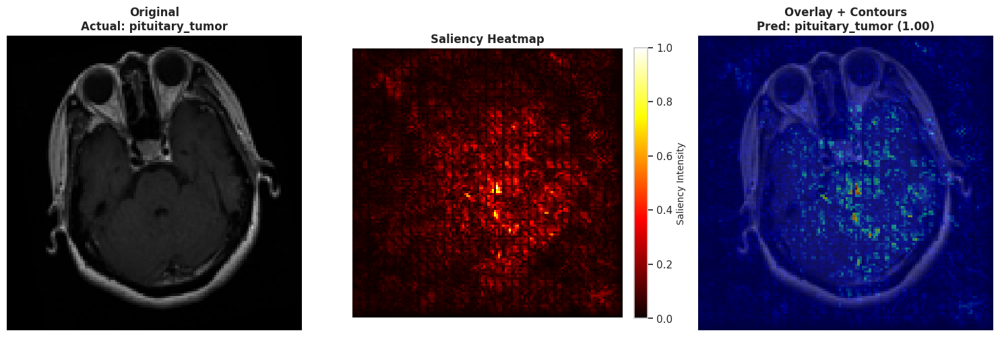

✅ Saved: saliency_contours/saliency_6.png | Prediction: pituitary_tumor (1.0000) | Actual: pituitary_tumor


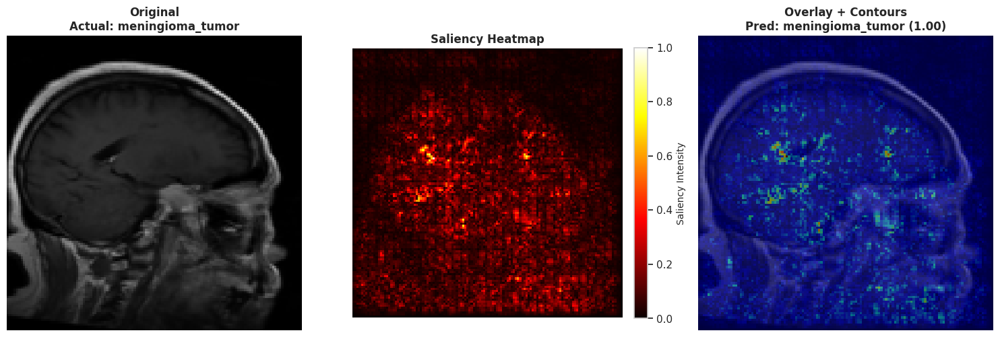

✅ Saved: saliency_contours/saliency_7.png | Prediction: meningioma_tumor (1.0000) | Actual: meningioma_tumor


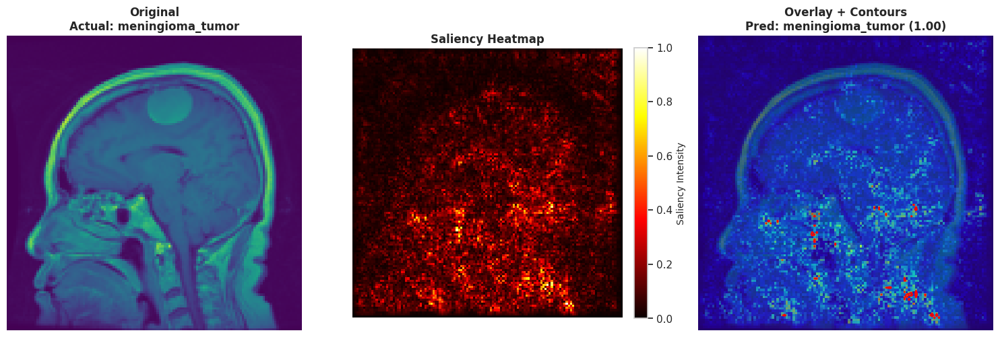

✅ Saved: saliency_contours/saliency_8.png | Prediction: meningioma_tumor (1.0000) | Actual: meningioma_tumor


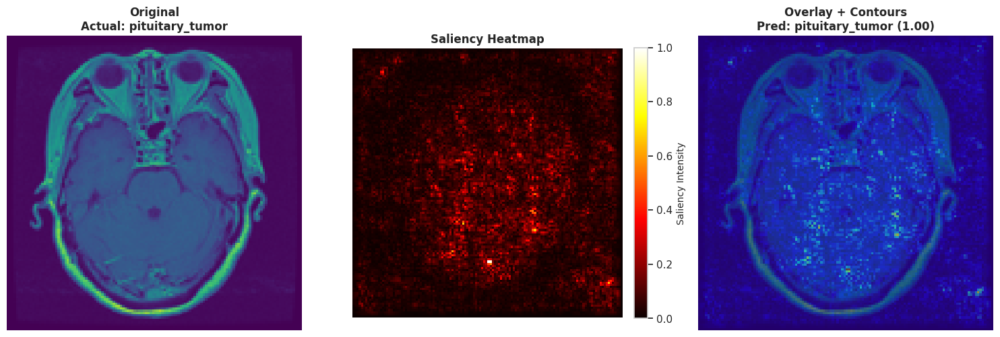

✅ Saved: saliency_contours/saliency_9.png | Prediction: pituitary_tumor (1.0000) | Actual: pituitary_tumor


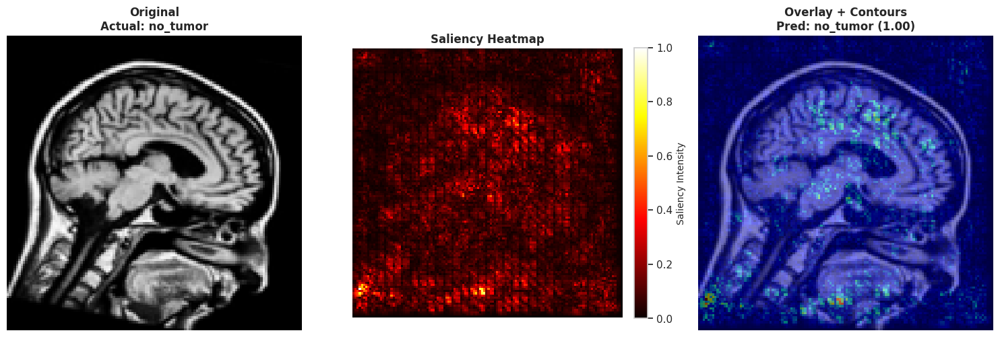

✅ Saved: saliency_contours/saliency_10.png | Prediction: no_tumor (1.0000) | Actual: no_tumor


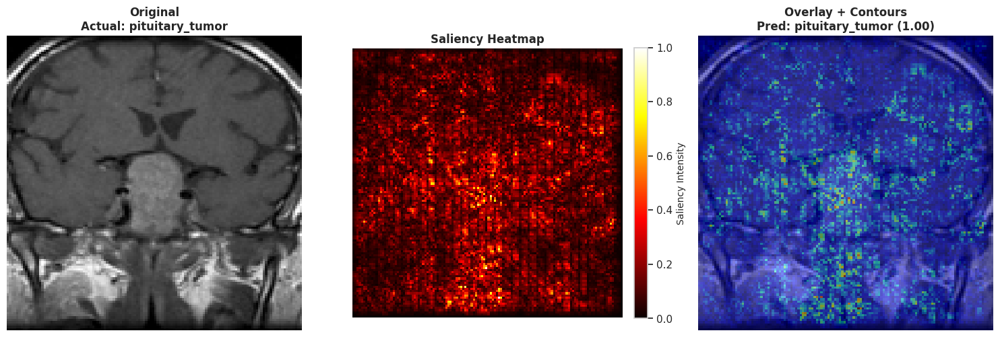

✅ Saved: saliency_contours/saliency_11.png | Prediction: pituitary_tumor (1.0000) | Actual: pituitary_tumor


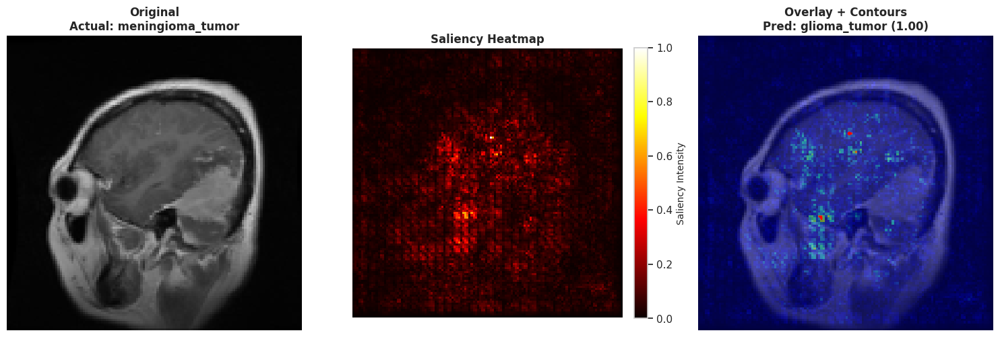

✅ Saved: saliency_contours/saliency_12.png | Prediction: glioma_tumor (0.9976) | Actual: meningioma_tumor


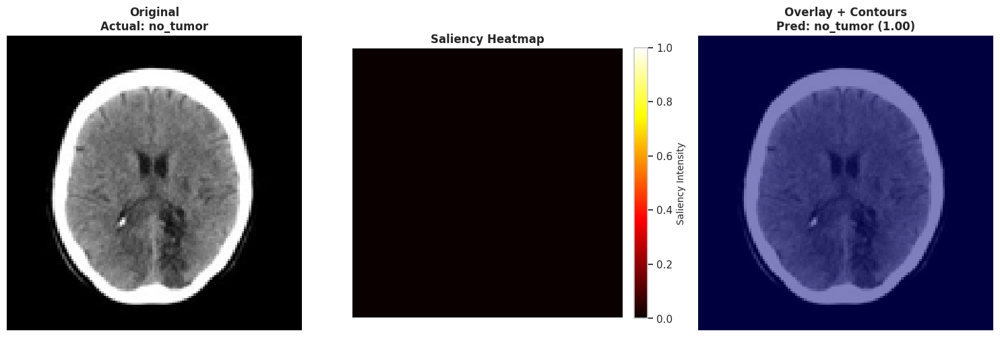

✅ Saved: saliency_contours/saliency_13.png | Prediction: no_tumor (1.0000) | Actual: no_tumor


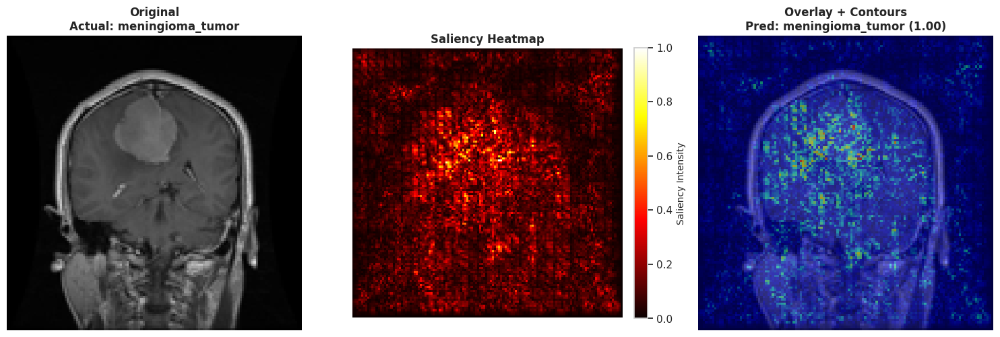

✅ Saved: saliency_contours/saliency_14.png | Prediction: meningioma_tumor (1.0000) | Actual: meningioma_tumor


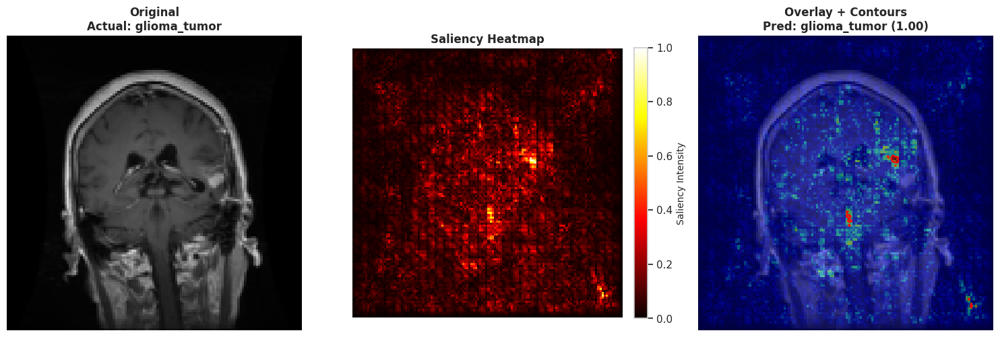

✅ Saved: saliency_contours/saliency_15.png | Prediction: glioma_tumor (1.0000) | Actual: glioma_tumor


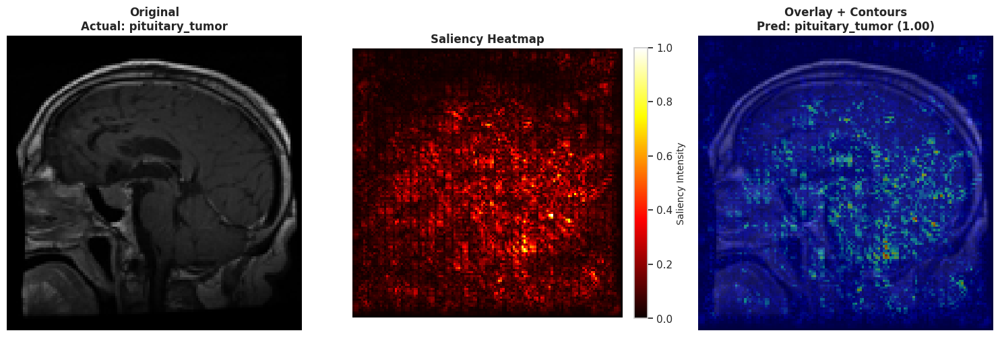

✅ Saved: saliency_contours/saliency_16.png | Prediction: pituitary_tumor (1.0000) | Actual: pituitary_tumor


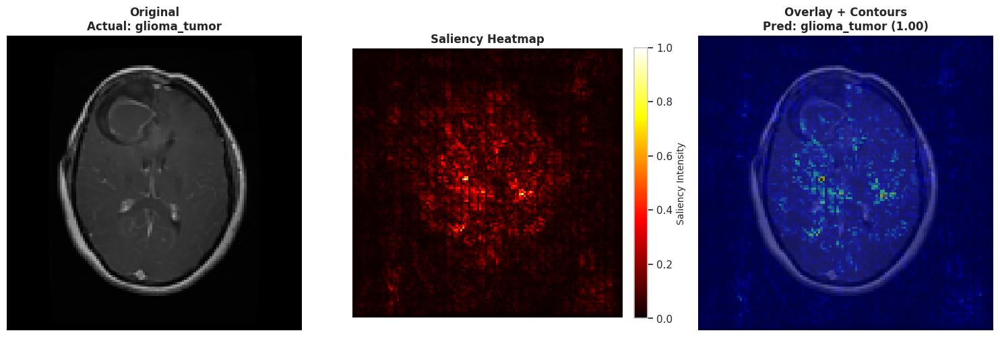

✅ Saved: saliency_contours/saliency_17.png | Prediction: glioma_tumor (1.0000) | Actual: glioma_tumor


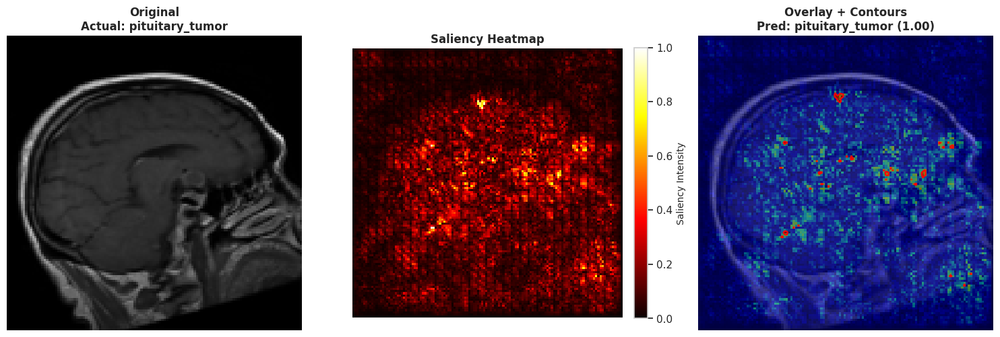

✅ Saved: saliency_contours/saliency_18.png | Prediction: pituitary_tumor (1.0000) | Actual: pituitary_tumor


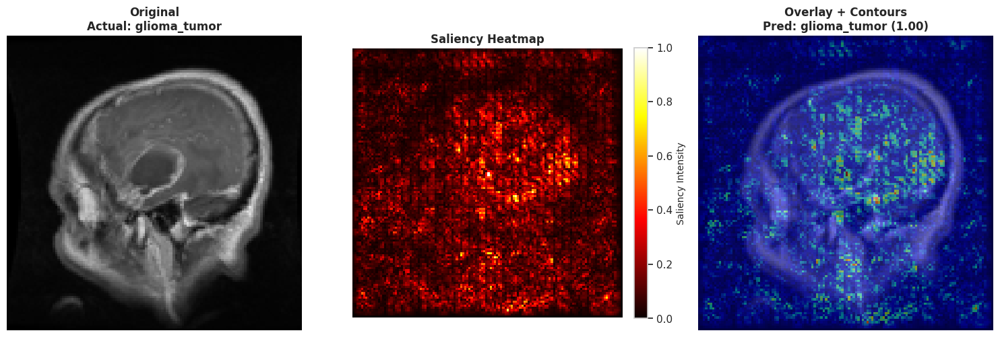

✅ Saved: saliency_contours/saliency_19.png | Prediction: glioma_tumor (1.0000) | Actual: glioma_tumor


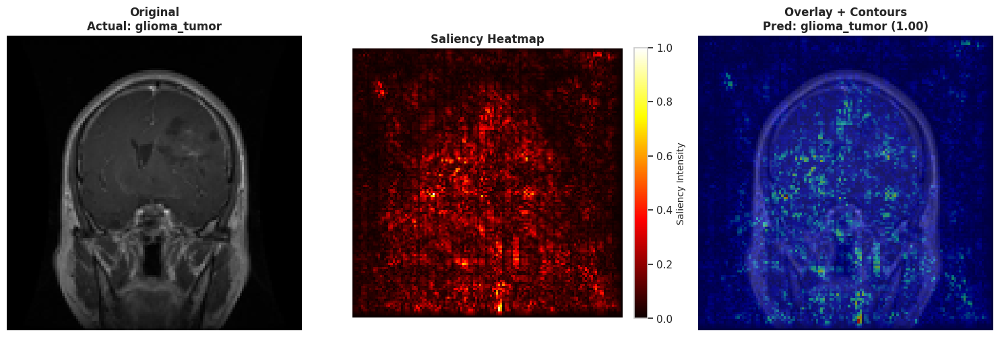

✅ Saved: saliency_contours/saliency_20.png | Prediction: glioma_tumor (1.0000) | Actual: glioma_tumor


In [33]:
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
import os

# -----------------------------
# Fixed Label Order
# -----------------------------
fixed_label_order = ["no_tumor", "pituitary_tumor", "meningioma_tumor", "glioma_tumor"]
display_labels = fixed_label_order

# -----------------------------
# Helper Functions
# -----------------------------
def preprocess_image(img_path, target_size=(128,128)):
    img = Image.open(img_path).convert("RGB")
    img = img.resize(target_size)
    img_array = np.array(img)/255.0
    return img_array

def get_actual_label(img_path):
    folder_name = os.path.basename(os.path.dirname(img_path))
    return folder_name if folder_name in display_labels else "Unknown"

def compute_saliency_map(model, img_array):
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
    img_tensor = tf.expand_dims(img_tensor, axis=0) 

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        predictions = model(img_tensor)
        class_idx = tf.argmax(predictions[0])
        class_output = predictions[0][class_idx]

    gradients = tape.gradient(class_output, img_tensor)
    saliency_map = np.max(np.abs(gradients.numpy()[0]), axis=-1)
    saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min() + 1e-8)
    return saliency_map, class_idx, predictions[0][class_idx]

def get_random_test_images(test_dir, n=6):
    all_image_paths = []
    for folder_name in display_labels:
        folder_path = os.path.join(test_dir, folder_name)
        if os.path.exists(folder_path):
            images_in_folder = [
                os.path.join(folder_path, f)
                for f in os.listdir(folder_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]
            all_image_paths.extend(images_in_folder)
    selected = np.random.choice(all_image_paths, min(n, len(all_image_paths)), replace=False)
    return selected

# -----------------------------
# Advanced Saliency Visualization with Contours
# -----------------------------
def plot_saliency_with_contours(model, img_paths, contour_threshold=0.6, save_dir="saliency_contours"):
    os.makedirs(save_dir, exist_ok=True)

    for idx, img_path in enumerate(img_paths):
        img_array = preprocess_image(img_path)
        actual_label = get_actual_label(img_path)
        saliency_map, pred_idx, pred_prob = compute_saliency_map(model, img_array)
        pred_label = display_labels[pred_idx]

        orig_img = Image.fromarray((img_array*255).astype(np.uint8))

        fig, axes = plt.subplots(1,3, figsize=(15,5))

        # 1️⃣ Original
        axes[0].imshow(orig_img)
        axes[0].axis('off')
        axes[0].set_title(f"Original\nActual: {actual_label}", fontsize=12, fontweight='bold')

        # 2️⃣ Saliency Heatmap
        axes[1].imshow(saliency_map, cmap='hot')
        axes[1].axis('off')
        axes[1].set_title("Saliency Heatmap", fontsize=12, fontweight='bold')
        cbar = fig.colorbar(cm.ScalarMappable(cmap='hot'), ax=axes[1], fraction=0.046, pad=0.04)
        cbar.set_label("Saliency Intensity", fontsize=10)

        # 3️⃣ Overlay with Contours
        axes[2].imshow(orig_img)
        axes[2].imshow(saliency_map, cmap='jet', alpha=0.5)
        # Draw contour lines
        contour_levels = [contour_threshold]
        axes[2].contour(saliency_map, levels=contour_levels, colors='red', linewidths=1.5)
        axes[2].axis('off')
        axes[2].set_title(f"Overlay + Contours\nPred: {pred_label} ({pred_prob:.2f})", fontsize=12, fontweight='bold')

        plt.tight_layout()
        save_path = os.path.join(save_dir, f"saliency_{idx+1}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

        print(f"✅ Saved: {save_path} | Prediction: {pred_label} ({pred_prob:.4f}) | Actual: {actual_label}")

# -----------------------------
# Usage Example
# -----------------------------
img_paths = get_random_test_images("/kaggle/input/elite-lab-dataset/tumordata/Training", n=20)
plot_saliency_with_contours(model, img_paths)


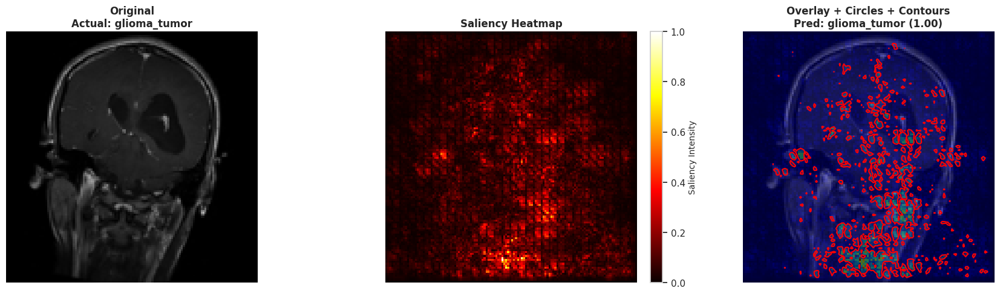

✅ Saved: saliency_publication/saliency_1.png | Prediction: glioma_tumor (1.0000) | Actual: glioma_tumor


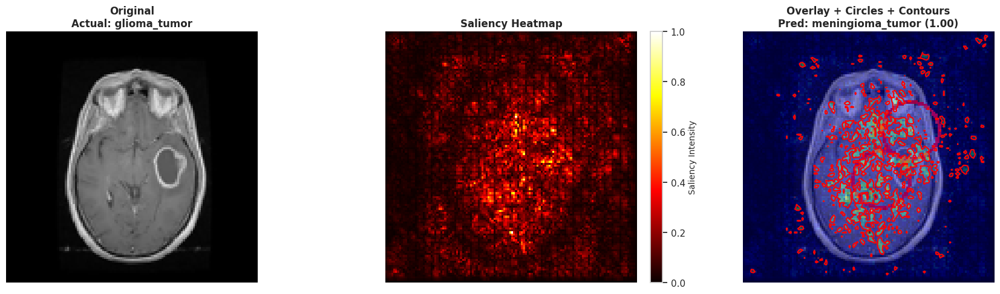

✅ Saved: saliency_publication/saliency_2.png | Prediction: meningioma_tumor (1.0000) | Actual: glioma_tumor


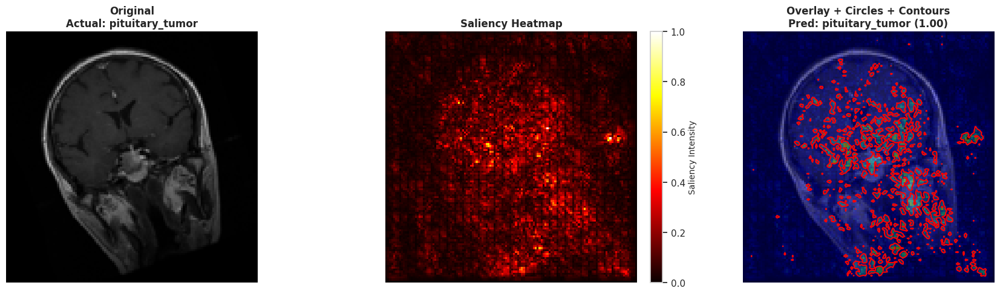

✅ Saved: saliency_publication/saliency_3.png | Prediction: pituitary_tumor (1.0000) | Actual: pituitary_tumor


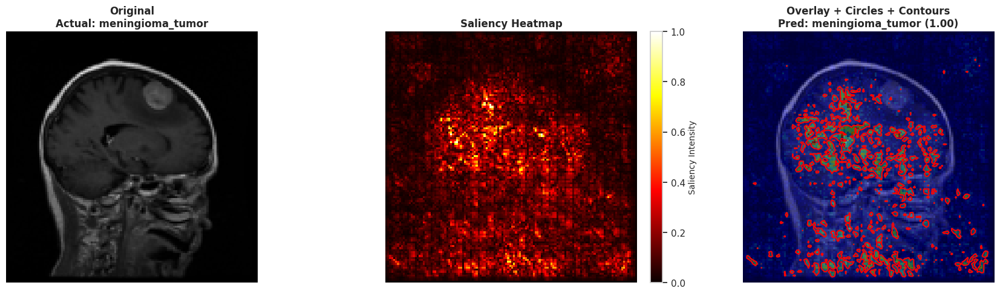

✅ Saved: saliency_publication/saliency_4.png | Prediction: meningioma_tumor (1.0000) | Actual: meningioma_tumor


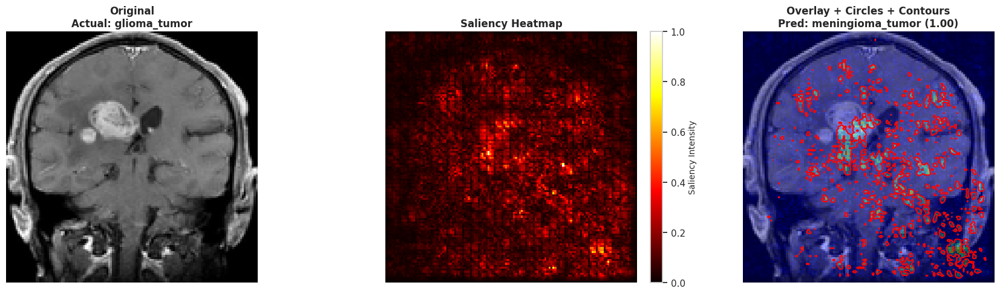

✅ Saved: saliency_publication/saliency_5.png | Prediction: meningioma_tumor (1.0000) | Actual: glioma_tumor


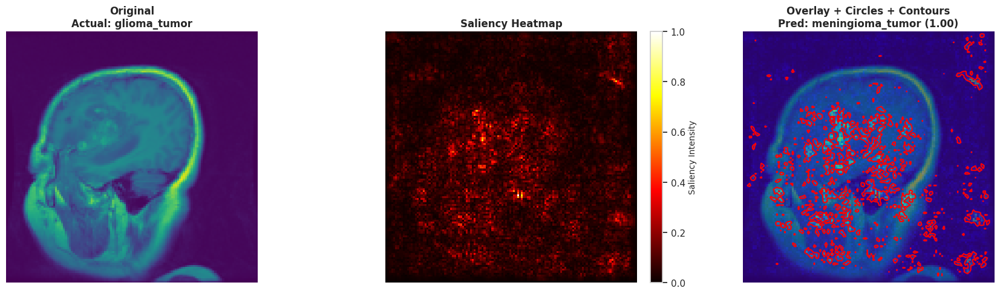

✅ Saved: saliency_publication/saliency_6.png | Prediction: meningioma_tumor (1.0000) | Actual: glioma_tumor


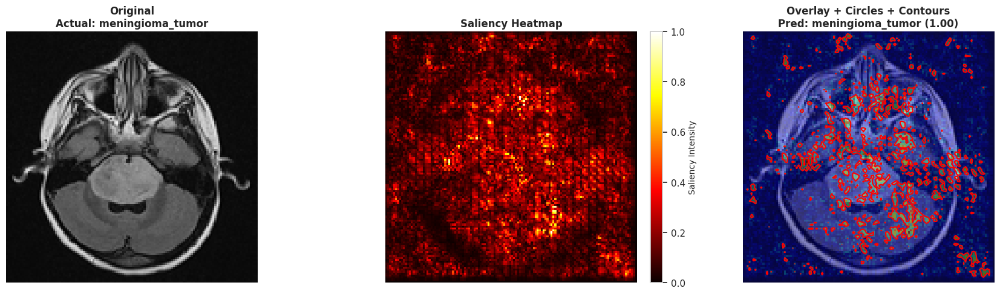

✅ Saved: saliency_publication/saliency_7.png | Prediction: meningioma_tumor (1.0000) | Actual: meningioma_tumor


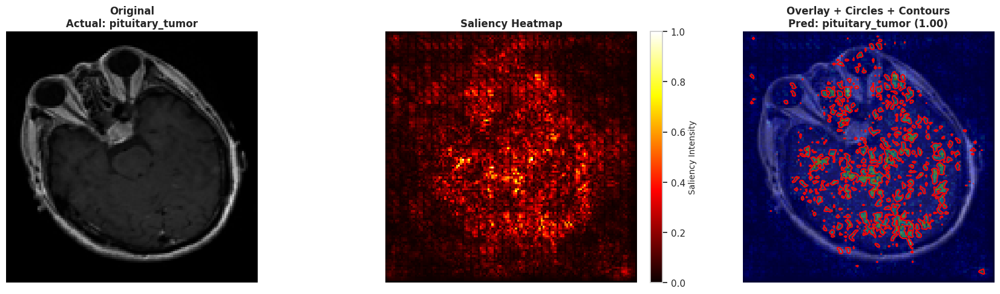

✅ Saved: saliency_publication/saliency_8.png | Prediction: pituitary_tumor (1.0000) | Actual: pituitary_tumor


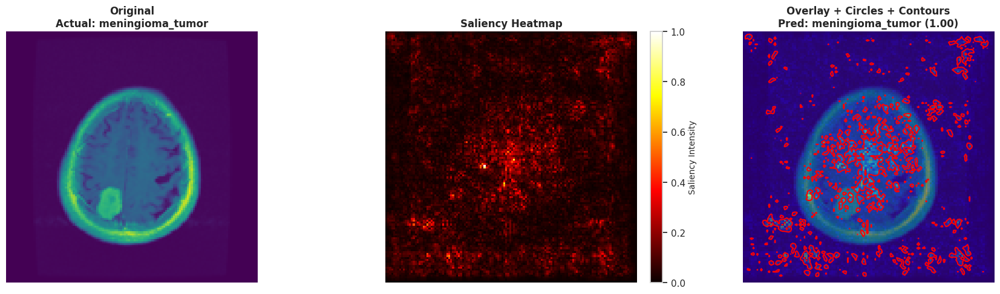

✅ Saved: saliency_publication/saliency_9.png | Prediction: meningioma_tumor (1.0000) | Actual: meningioma_tumor


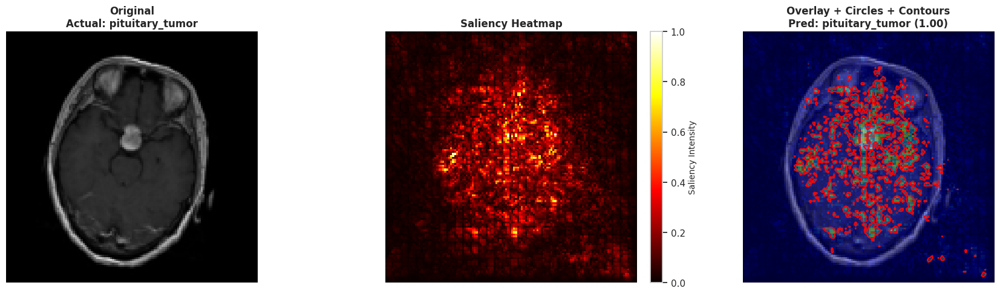

✅ Saved: saliency_publication/saliency_10.png | Prediction: pituitary_tumor (1.0000) | Actual: pituitary_tumor


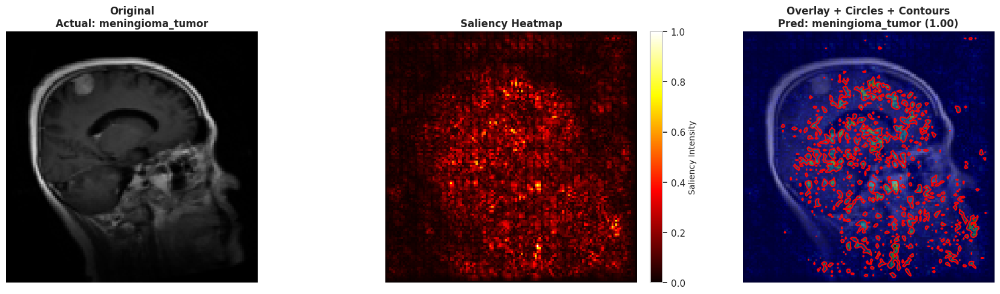

✅ Saved: saliency_publication/saliency_11.png | Prediction: meningioma_tumor (1.0000) | Actual: meningioma_tumor


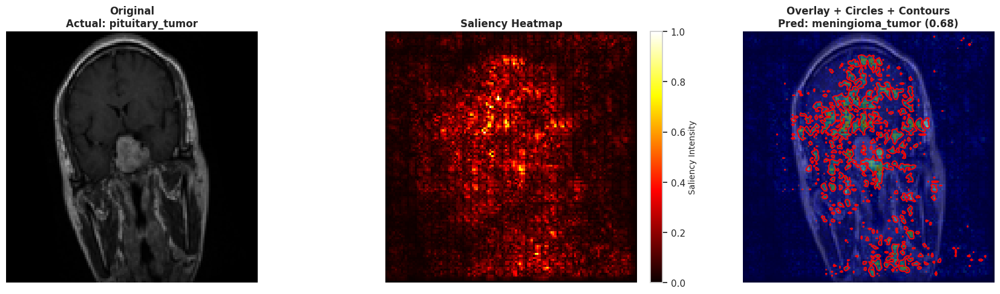

✅ Saved: saliency_publication/saliency_12.png | Prediction: meningioma_tumor (0.6830) | Actual: pituitary_tumor


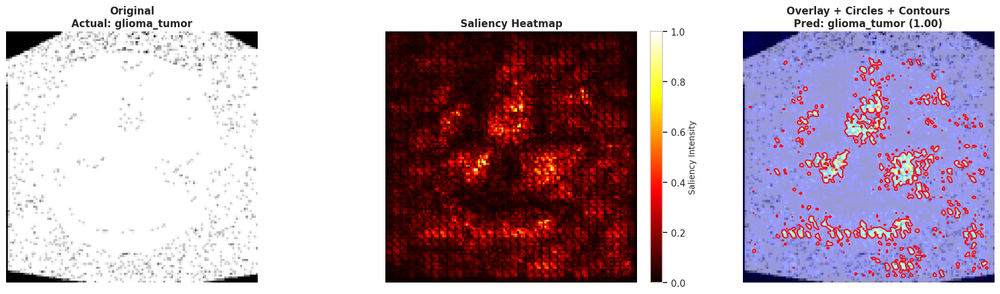

✅ Saved: saliency_publication/saliency_13.png | Prediction: glioma_tumor (1.0000) | Actual: glioma_tumor


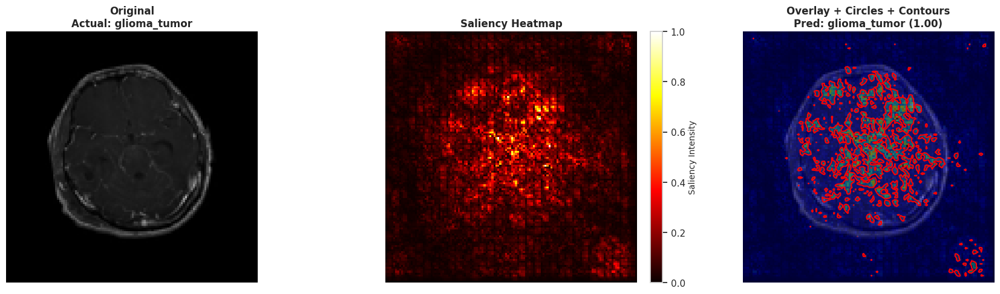

✅ Saved: saliency_publication/saliency_14.png | Prediction: glioma_tumor (1.0000) | Actual: glioma_tumor


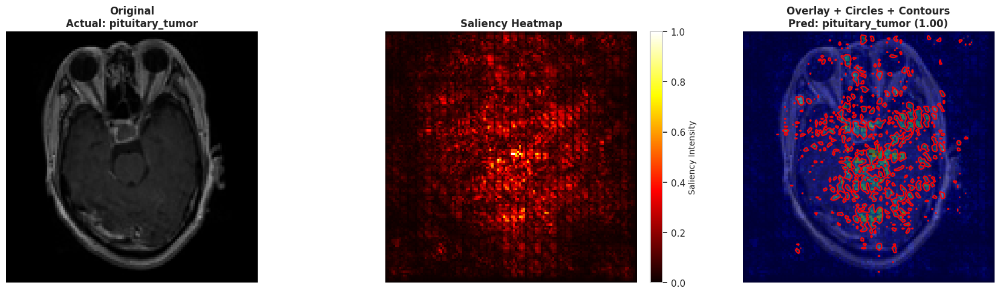

✅ Saved: saliency_publication/saliency_15.png | Prediction: pituitary_tumor (1.0000) | Actual: pituitary_tumor


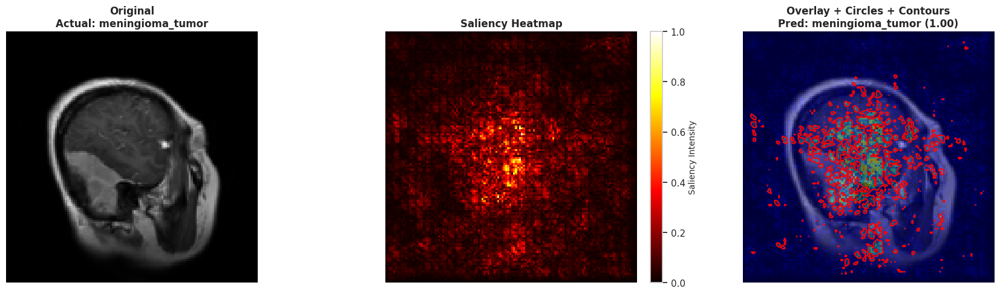

✅ Saved: saliency_publication/saliency_16.png | Prediction: meningioma_tumor (1.0000) | Actual: meningioma_tumor


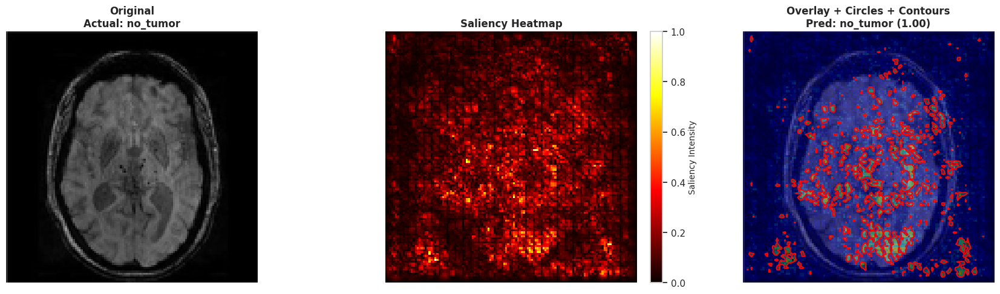

✅ Saved: saliency_publication/saliency_17.png | Prediction: no_tumor (1.0000) | Actual: no_tumor


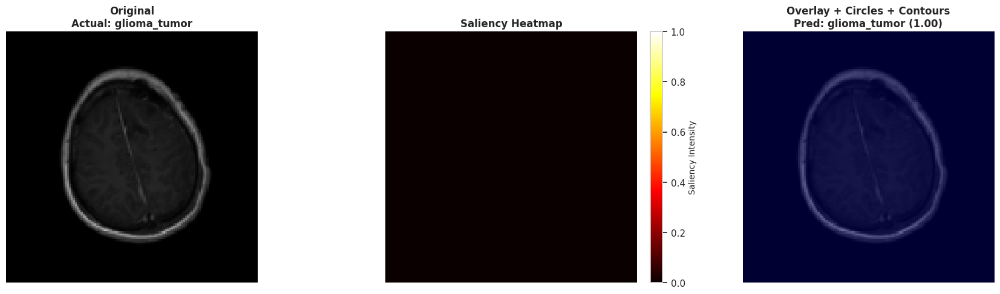

✅ Saved: saliency_publication/saliency_18.png | Prediction: glioma_tumor (1.0000) | Actual: glioma_tumor


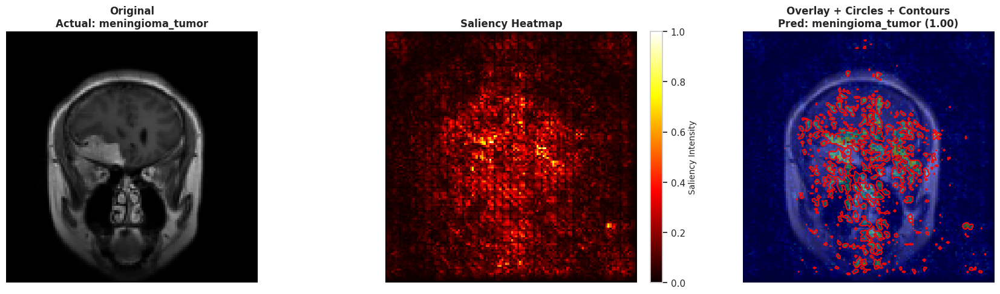

✅ Saved: saliency_publication/saliency_19.png | Prediction: meningioma_tumor (1.0000) | Actual: meningioma_tumor


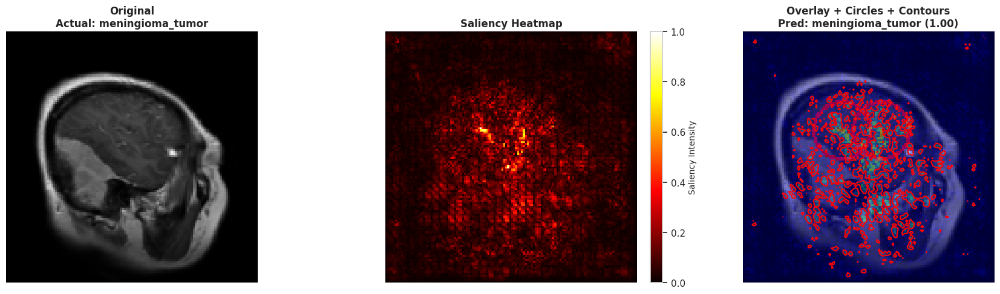

✅ Saved: saliency_publication/saliency_20.png | Prediction: meningioma_tumor (0.9999) | Actual: meningioma_tumor


In [34]:
import os
import numpy as np
import tensorflow as tf
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# -----------------------------
# Fixed Label Order
# -----------------------------
fixed_label_order = ["no_tumor", "pituitary_tumor", "meningioma_tumor", "glioma_tumor"]
display_labels = fixed_label_order

# -----------------------------
# Helper Functions
# -----------------------------
def preprocess_image(img_path, target_size=(128,128)):
    """Load and normalize image"""
    img = Image.open(img_path).convert("RGB")
    img = img.resize(target_size)
    img_array = np.array(img)/255.0
    return img_array

def get_actual_label(img_path):
    folder_name = os.path.basename(os.path.dirname(img_path))
    return folder_name if folder_name in display_labels else "Unknown"

def compute_saliency_map(model, img_array):
    """
    Compute saliency map and prediction
    Returns: saliency_map, predicted_class_index, predicted_probability
    """
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
    img_tensor = tf.expand_dims(img_tensor, axis=0)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        predictions = model(img_tensor)
        class_idx = tf.argmax(predictions[0])
        class_output = predictions[0][class_idx]

    gradients = tape.gradient(class_output, img_tensor)
    saliency_map = np.max(np.abs(gradients.numpy()[0]), axis=-1)
    # Normalize
    saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min() + 1e-8)
    return saliency_map, class_idx, predictions[0][class_idx]

def draw_circles_on_saliency(img_array, saliency_map, threshold=0.6, radius=15, step=5):
    """
    Draw circles on high-saliency regions
    """
    img_pil = Image.fromarray((img_array*255).astype(np.uint8))
    draw = ImageDraw.Draw(img_pil)

    h, w = saliency_map.shape
    for i in range(0, h, step):
        for j in range(0, w, step):
            if saliency_map[i,j] > threshold:
                draw.ellipse((j-radius, i-radius, j+radius, i+radius), outline="red", width=2)
    return img_pil

def get_random_test_images(test_dir, n=6):
    all_image_paths = []
    for folder_name in display_labels:
        folder_path = os.path.join(test_dir, folder_name)
        if os.path.exists(folder_path):
            images_in_folder = [
                os.path.join(folder_path, f)
                for f in os.listdir(folder_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]
            all_image_paths.extend(images_in_folder)
    selected = np.random.choice(all_image_paths, min(n, len(all_image_paths)), replace=False)
    return selected

# -----------------------------
# Advanced Saliency Plotting
# -----------------------------
def plot_saliency_with_circles_and_contours(model, img_paths, top_percent=0.1, circle_threshold=0.6, save_dir="saliency_publication"):
    os.makedirs(save_dir, exist_ok=True)

    for idx, img_path in enumerate(img_paths):
        img_array = preprocess_image(img_path)
        actual_label = get_actual_label(img_path)
        saliency_map, pred_idx, pred_prob = compute_saliency_map(model, img_array)
        pred_label = display_labels[pred_idx]

        # Adaptive contour threshold: top X% of saliency values
        flat_saliency = saliency_map.flatten()
        contour_threshold = np.percentile(flat_saliency, 100*(1-top_percent))

        # Draw circles for tumor regions
        img_with_circles = draw_circles_on_saliency(img_array, saliency_map, threshold=circle_threshold)

        orig_img = Image.fromarray((img_array*255).astype(np.uint8))

        fig, axes = plt.subplots(1,3, figsize=(18,5))

        # 1️⃣ Original Image
        axes[0].imshow(orig_img)
        axes[0].axis('off')
        axes[0].set_title(f"Original\nActual: {actual_label}", fontsize=12, fontweight='bold')

        # 2️⃣ Saliency Heatmap
        axes[1].imshow(saliency_map, cmap='hot')
        axes[1].axis('off')
        axes[1].set_title("Saliency Heatmap", fontsize=12, fontweight='bold')
        cbar = fig.colorbar(cm.ScalarMappable(cmap='hot'), ax=axes[1], fraction=0.046, pad=0.04)
        cbar.set_label("Saliency Intensity", fontsize=10)

        # 3️⃣ Overlay: Saliency + Contours + Circles
        axes[2].imshow(img_with_circles)
        axes[2].imshow(saliency_map, cmap='jet', alpha=0.4)
        axes[2].contour(saliency_map, levels=[contour_threshold], colors='red', linewidths=1.5)
        axes[2].axis('off')
        axes[2].set_title(f"Overlay + Circles + Contours\nPred: {pred_label} ({pred_prob:.2f})", fontsize=12, fontweight='bold')

        plt.tight_layout()
        save_path = os.path.join(save_dir, f"saliency_{idx+1}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

        print(f"✅ Saved: {save_path} | Prediction: {pred_label} ({pred_prob:.4f}) | Actual: {actual_label}")

# -----------------------------
# Usage Example
# -----------------------------

# Get random test images
test_dir = "/kaggle/input/elite-lab-dataset/tumordata/Testing"
img_paths = get_random_test_images(test_dir, n=20)

# Plot advanced saliency visualizations
plot_saliency_with_circles_and_contours(model, img_paths, top_percent=0.1, circle_threshold=0.6)


📌 Randomly selected test images:
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/meningioma_tumor/3001.png
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/Glioma_test_440.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/pituitary_tumor/2225.png
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/HR_img (818).png
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/no_tumor/NoTumor_test_2634.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/pituitary_tumor/Pituitary_test_2462.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/meningioma_tumor/Meningioma_test_2385.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/meningioma_tumor/Meningioma_test_627.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/meningioma_tumor/Meningioma_test_2604.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/Glioma_test_338.jpg
   - /kaggle/input/elite-lab-dataset/tumordata/Testing/glioma_tumor/1898.

  0%|          | 0/1000 [00:00<?, ?it/s]

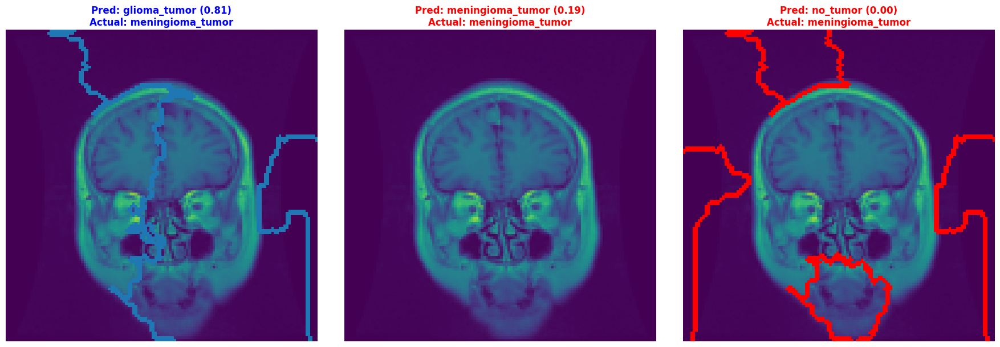

✅ Advanced LIME overlay saved: lime_outputs_advanced/3001_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

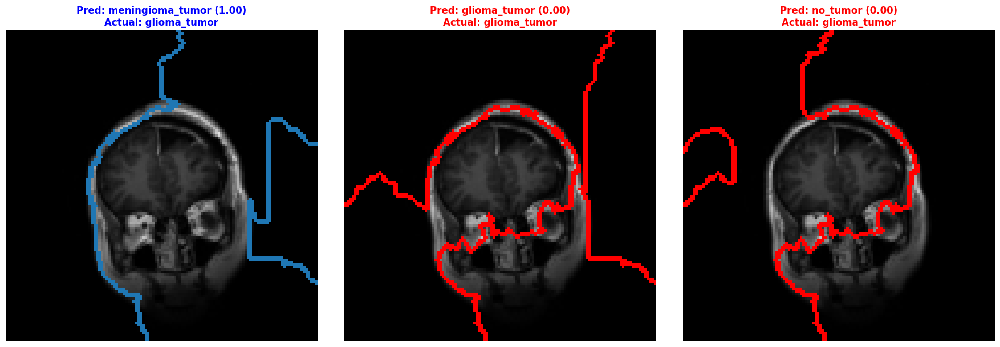

✅ Advanced LIME overlay saved: lime_outputs_advanced/Glioma_test_440_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

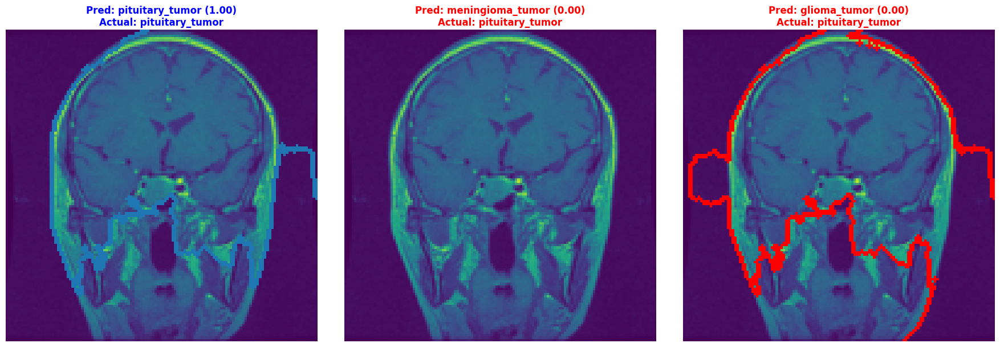

✅ Advanced LIME overlay saved: lime_outputs_advanced/2225_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

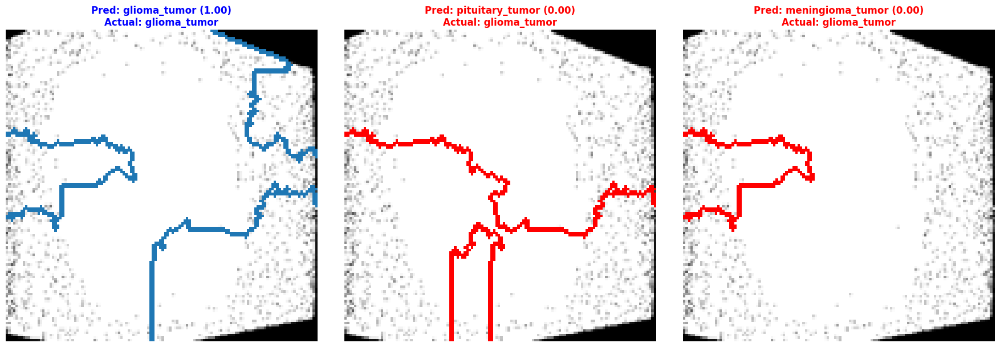

✅ Advanced LIME overlay saved: lime_outputs_advanced/HR_img (818)_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

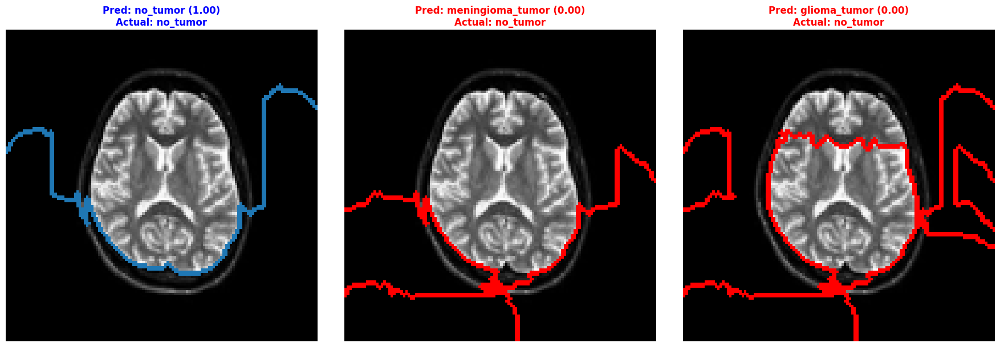

✅ Advanced LIME overlay saved: lime_outputs_advanced/NoTumor_test_2634_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

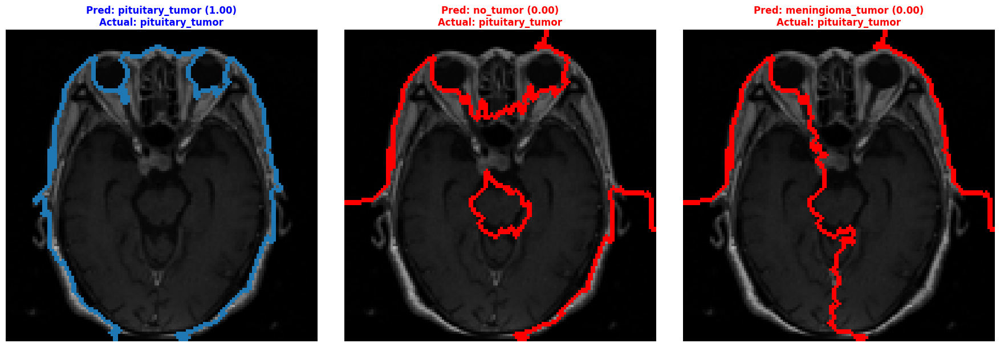

✅ Advanced LIME overlay saved: lime_outputs_advanced/Pituitary_test_2462_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

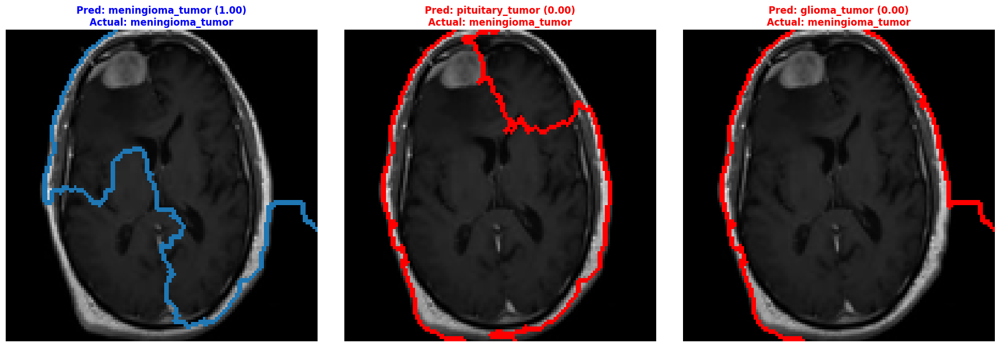

✅ Advanced LIME overlay saved: lime_outputs_advanced/Meningioma_test_2385_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

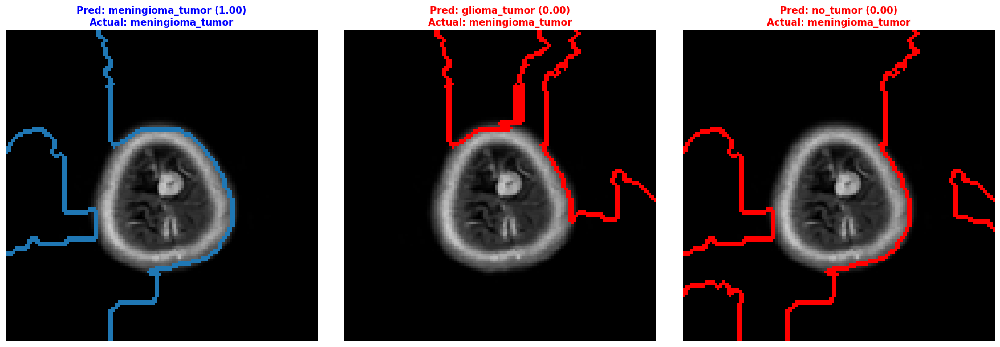

✅ Advanced LIME overlay saved: lime_outputs_advanced/Meningioma_test_627_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

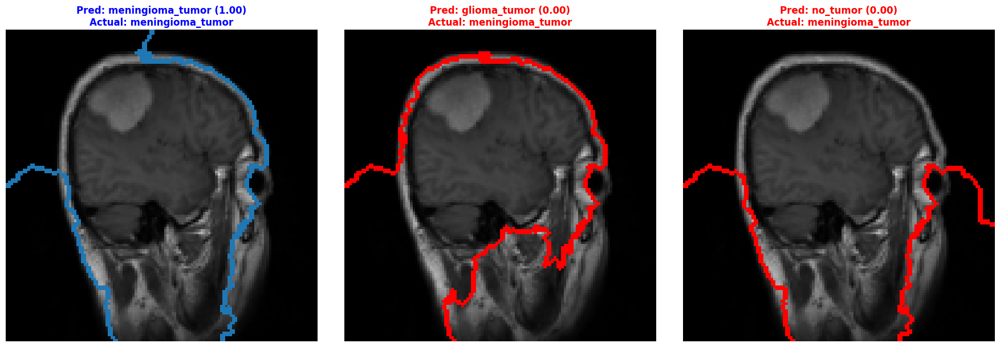

✅ Advanced LIME overlay saved: lime_outputs_advanced/Meningioma_test_2604_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

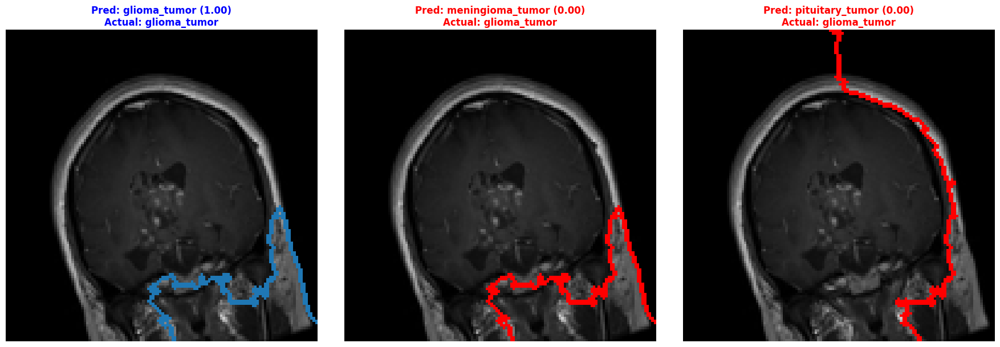

✅ Advanced LIME overlay saved: lime_outputs_advanced/Glioma_test_338_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

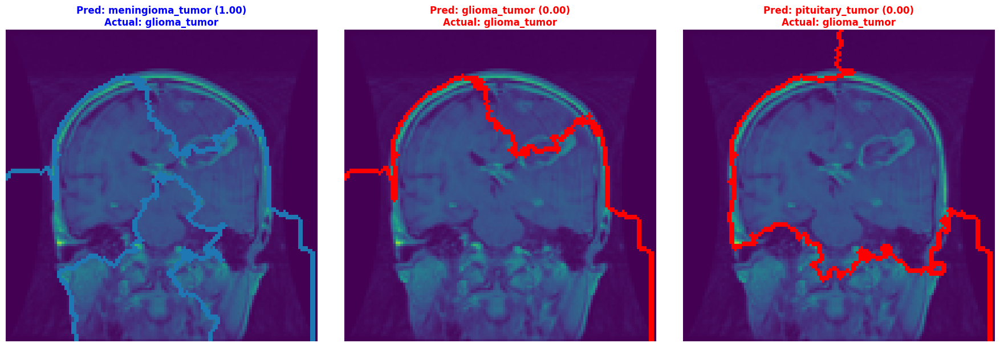

✅ Advanced LIME overlay saved: lime_outputs_advanced/1898_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

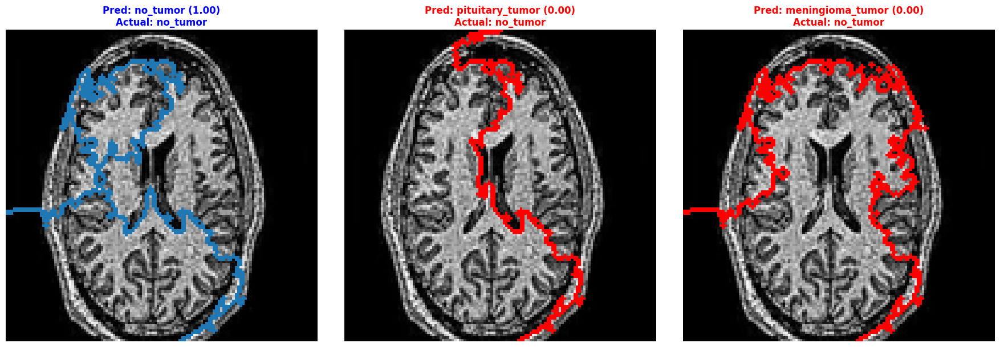

✅ Advanced LIME overlay saved: lime_outputs_advanced/NoTumor_test_1770_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

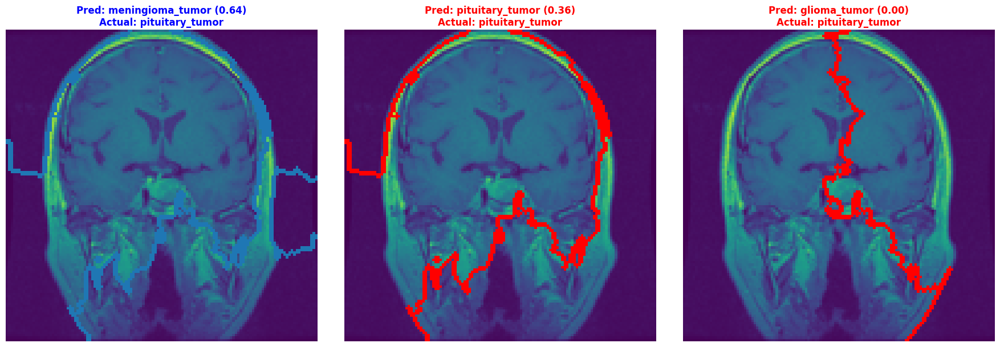

✅ Advanced LIME overlay saved: lime_outputs_advanced/2138_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

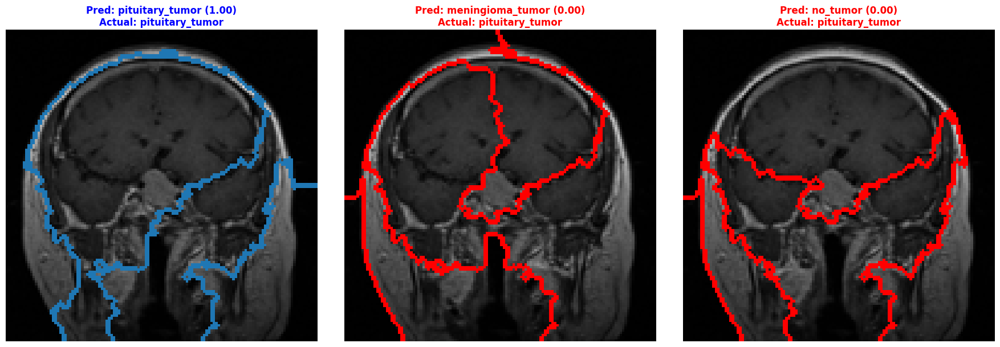

✅ Advanced LIME overlay saved: lime_outputs_advanced/Pituitary_test_870_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

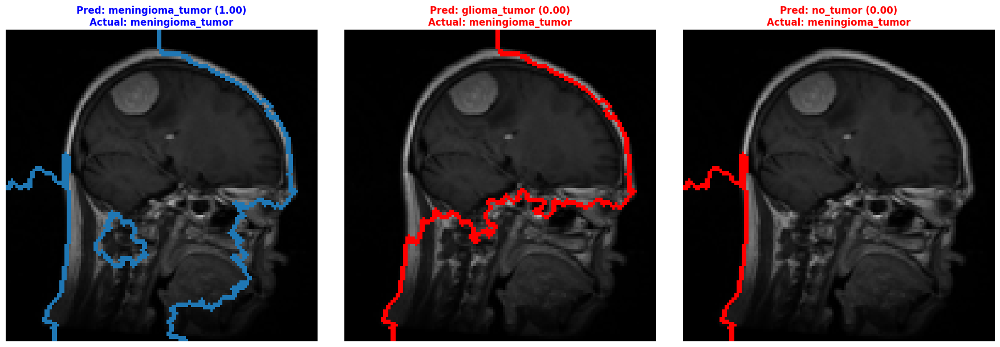

✅ Advanced LIME overlay saved: lime_outputs_advanced/Meningioma_test_1584_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

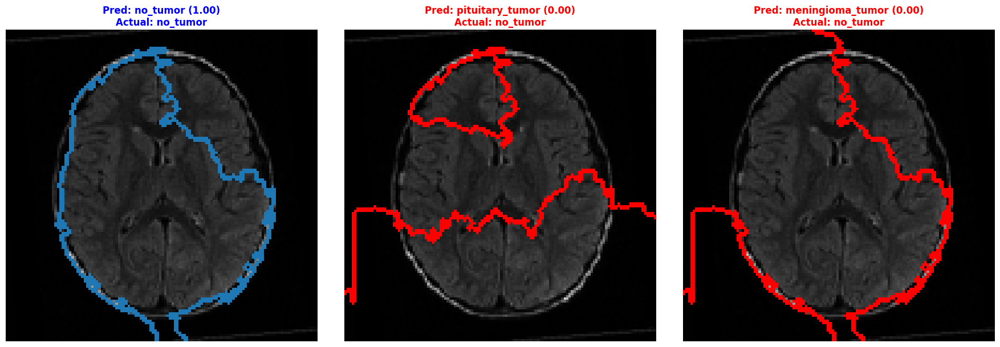

✅ Advanced LIME overlay saved: lime_outputs_advanced/NoTumor_test_873_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

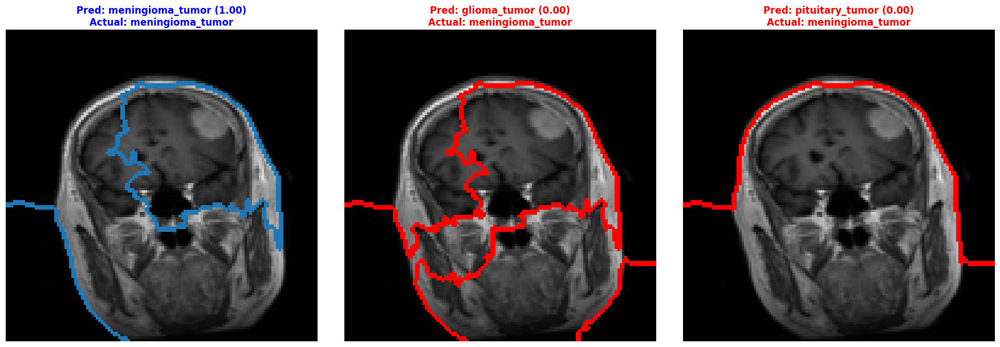

✅ Advanced LIME overlay saved: lime_outputs_advanced/Meningioma_test_1618_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

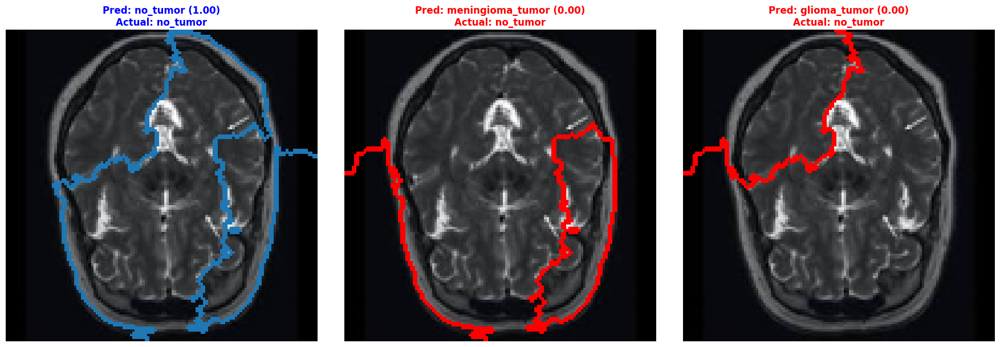

✅ Advanced LIME overlay saved: lime_outputs_advanced/healthy (324)_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

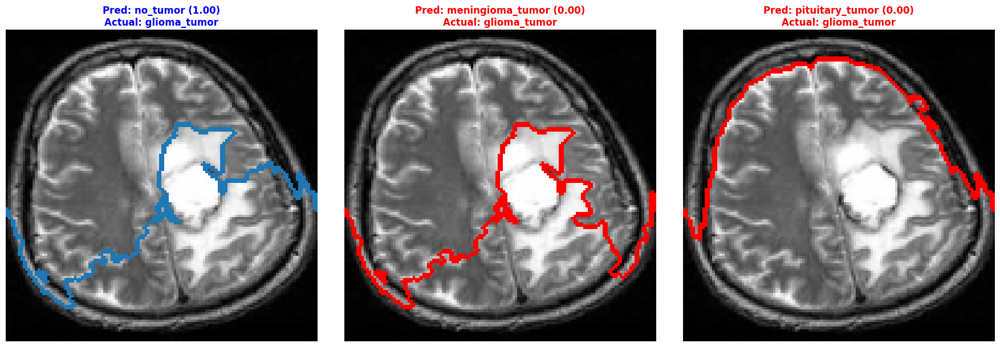

✅ Advanced LIME overlay saved: lime_outputs_advanced/image(84)_lime_overlay.png


  0%|          | 0/1000 [00:00<?, ?it/s]

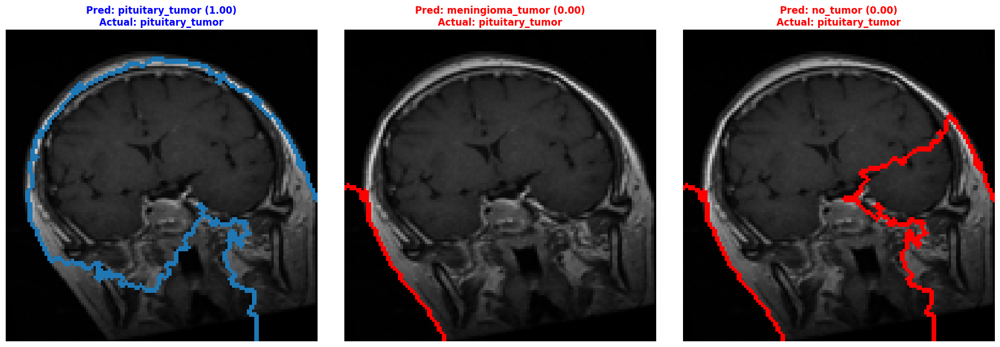

✅ Advanced LIME overlay saved: lime_outputs_advanced/Pituitary_test_1438_lime_overlay.png


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from PIL import Image
import os
import random

# -----------------------------------
# Fixed Label Order
# -----------------------------------
fixed_label_order = ["no_tumor", "pituitary_tumor", "meningioma_tumor", "glioma_tumor"]
display_labels = fixed_label_order

# -----------------------------------
# Helper Functions
# -----------------------------------
def preprocess_image(img_path, target_size=(128,128)):
    """Load and preprocess image"""
    img = Image.open(img_path).convert("RGB")
    img = img.resize(target_size)
    img_array = np.array(img)/255.0
    return img_array

def get_actual_label(img_path):
    """Map folder to fixed label order"""
    folder_name = os.path.basename(os.path.dirname(img_path))
    return folder_name if folder_name in display_labels else "Unknown"

def get_random_test_images(test_dir, n=5):
    """Randomly select n images from all label folders"""
    all_image_paths = []
    for folder_name in display_labels:
        folder_path = os.path.join(test_dir, folder_name)
        if os.path.exists(folder_path):
            images_in_folder = [
                os.path.join(folder_path, f)
                for f in os.listdir(folder_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]
            all_image_paths.extend(images_in_folder)
    selected = random.sample(all_image_paths, min(n, len(all_image_paths)))
    print("\n📌 Randomly selected test images:")
    for p in selected:
        print("   -", p)
    return selected

# -----------------------------------
# LIME Prediction Wrapper
# -----------------------------------
explainer = lime_image.LimeImageExplainer()

def predict_fn(images):
    """Wrap model prediction for LIME; images are uint8 [0,255]"""
    images = np.array(images).astype(np.float32) / 255.0
    preds = model.predict(images, verbose=0)
    return preds

# -----------------------------------
# Advanced LIME Overlay Function
# -----------------------------------
def explain_image_with_lime_overlay(img_path, top_labels=3, num_samples=1000, num_features=5, hide_color=0):
    img_array = preprocess_image(img_path)
    img_uint8 = (img_array * 255).astype(np.uint8)
    explanation = explainer.explain_instance(
        image=img_uint8,
        classifier_fn=predict_fn,
        top_labels=top_labels,
        hide_color=hide_color,
        num_samples=num_samples
    )
    actual_label = get_actual_label(img_path)
    
    fig, axes = plt.subplots(1, top_labels, figsize=(6*top_labels, 6))
    if top_labels == 1:
        axes = [axes]
    
    for i, top_label in enumerate(explanation.top_labels[:top_labels]):
        temp, mask = explanation.get_image_and_mask(
            label=top_label,
            positive_only=True,
            num_features=num_features,
            hide_rest=False
        )
        
        # Prediction label and probability
        pred_label_name = display_labels[top_label]
        pred_prob = predict_fn([img_uint8])[0][top_label]
        
        # Overlay image
        overlay = temp / 255.0
        
        # Color distinction: top prediction → Blue, others → Red
        boundary_color = (31/255, 119/255, 180/255) if i == 0 else (1.0, 0.0, 0.0)
        text_color = 'blue' if i == 0 else 'red'
        
        axes[i].imshow(overlay)
        axes[i].imshow(mark_boundaries(overlay, mask, color=boundary_color, mode='thick'))
        axes[i].axis('off')
        axes[i].set_title(f"Pred: {pred_label_name} ({pred_prob:.2f})\nActual: {actual_label}",
                          fontsize=12, fontweight='bold', color=text_color)
    
    plt.tight_layout()
    save_dir = "lime_outputs_advanced"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, os.path.basename(img_path).split('.')[0] + "_lime_overlay.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Advanced LIME overlay saved: {save_path}")

# -----------------------------------
# Usage Example
# -----------------------------------
test_dir = "/kaggle/input/elite-lab-dataset/tumordata/Testing"
img_paths = get_random_test_images(test_dir, n=20)

for img_path in img_paths:
    explain_image_with_lime_overlay(img_path)

  0%|          | 0/498 [00:00<?, ?it/s]

Image: Meningioma_test_2047.jpg | Prediction: glioma_tumor (0.9999) | Actual: meningioma_tumor


  0%|          | 0/498 [00:00<?, ?it/s]

Image: NoTumor_test_2381.jpg | Prediction: pituitary_tumor (1.0000) | Actual: no_tumor
Image: NoTumor_test_1842.jpg | Prediction: no_tumor (1.0000) | Actual: no_tumor
Image: image(27).jpg | Prediction: no_tumor (1.0000) | Actual: glioma_tumor


  0%|          | 0/498 [00:00<?, ?it/s]

Image: Pituitary_test_1611.jpg | Prediction: pituitary_tumor (1.0000) | Actual: pituitary_tumor


  0%|          | 0/498 [00:00<?, ?it/s]

Image: 2242.png | Prediction: pituitary_tumor (1.0000) | Actual: pituitary_tumor


  0%|          | 0/498 [00:00<?, ?it/s]

Image: Pituitary_test_2210.jpg | Prediction: pituitary_tumor (1.0000) | Actual: pituitary_tumor
Image: NoTumor_test_1710.jpg | Prediction: no_tumor (1.0000) | Actual: no_tumor


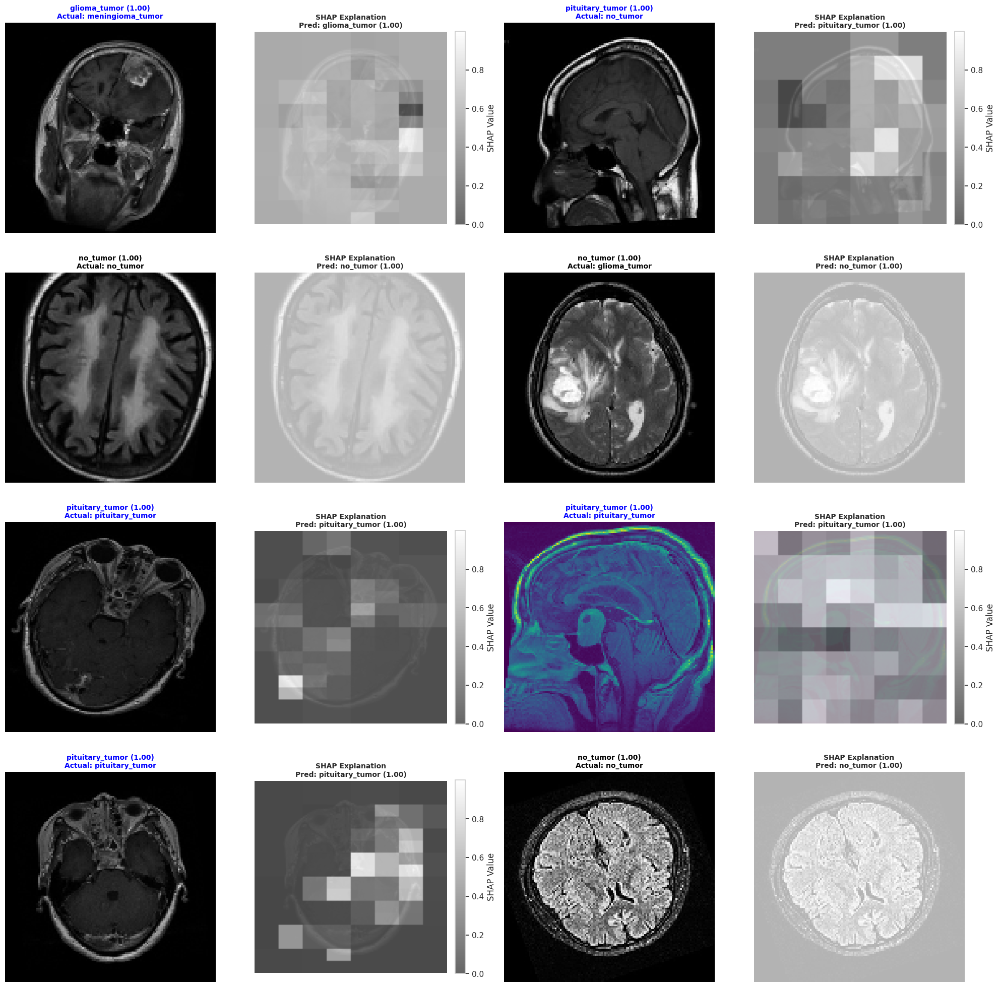

In [36]:
# ==============================================
# Advanced SHAP Visualization for Tumor Classification
# ==============================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import shap
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

# ----------------------------------------------
# Fixed Label Order
# ----------------------------------------------
fixed_label_order = ["no_tumor", "pituitary_tumor", "meningioma_tumor", "glioma_tumor"]
display_labels = fixed_label_order

# ----------------------------------------------
# Helper Functions
# ----------------------------------------------
def preprocess_image(img_path, target_size=(128,128)):
    """Load and preprocess image"""
    img = load_img(img_path, target_size=target_size)
    img_array = img_to_array(img) / 255.0
    return img_array

def get_actual_label(img_path):
    """Map folder to fixed label order"""
    folder_name = os.path.basename(os.path.dirname(img_path))
    return folder_name if folder_name in display_labels else "Unknown"

# ----------------------------------------------
# SHAP Explanation for a Single Image
# ----------------------------------------------
def compute_shap_explanation(model, img_path, img_size=128, skip_no_tumor=True):
    """Compute SHAP values and return normalized heatmap with prediction probability"""
    img_array = preprocess_image(img_path, target_size=(img_size,img_size))
    img_batch = np.expand_dims(img_array, axis=0)
    actual_label = get_actual_label(img_path)

    # Predict class
    preds = model.predict(img_batch, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_label = display_labels[pred_idx]
    pred_prob = preds[0][pred_idx]

    if skip_no_tumor and pred_label == "no_tumor":
        return img_array, None, pred_label, pred_prob, actual_label

    # Create SHAP explainer
    masker = shap.maskers.Image(mask_value=0, shape=(img_size,img_size,3))
    explainer = shap.Explainer(model, masker)

    shap_values = explainer(img_batch)
    shap_image = shap_values[0].values[..., pred_idx]

    # Normalize SHAP map
    shap_image_normalized = shap_image / (np.max(np.abs(shap_image)) + 1e-8)
    return img_array, shap_image_normalized, pred_label, pred_prob, actual_label

# ----------------------------------------------
# Display SHAP Explanations in Grid
# ----------------------------------------------
def display_shap_grid(model, image_paths, img_size=128, skip_no_tumor=True):
    """Display images in a 4x4 grid with SHAP heatmaps and prediction scores"""
    rows, cols = 4, 4
    plt.figure(figsize=(20, 20))
    
    for i, img_path in enumerate(image_paths[:8]):  # Up to 8 images (16 subplots)
        img_array, shap_map, pred_label, pred_prob, actual_label = compute_shap_explanation(
            model, img_path, img_size=img_size, skip_no_tumor=skip_no_tumor
        )

        # Print verbose info
        print(f"Image: {os.path.basename(img_path)} | Prediction: {pred_label} ({pred_prob:.4f}) | Actual: {actual_label}")

        # Original image
        plt.subplot(rows, cols, 2*i + 1)
        plt.imshow(img_array)
        plt.title(f"{pred_label} ({pred_prob:.2f})\nActual: {actual_label}", fontsize=10, fontweight='bold', color='blue' if pred_label!='no_tumor' else 'black')
        plt.axis('off')

        # SHAP heatmap overlay
        plt.subplot(rows, cols, 2*i + 2)
        plt.imshow(img_array, alpha=0.3)
        if shap_map is not None:
            shap_map_norm = (shap_map - shap_map.min()) / (shap_map.max() - shap_map.min() + 1e-8)
            plt.imshow(shap_map_norm, cmap='gray', alpha=0.6)
            plt.colorbar(label="SHAP Value", fraction=0.046, pad=0.04)
        plt.title(f"SHAP Explanation\nPred: {pred_label} ({pred_prob:.2f})", fontsize=10, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# ----------------------------------------------
# Randomized Test Image Selection
# ----------------------------------------------
def get_random_test_images(test_dir, n=8):
    all_image_paths = []
    for folder_name in display_labels:
        folder_path = os.path.join(test_dir, folder_name)
        if os.path.exists(folder_path):
            images = [
                os.path.join(folder_path, f)
                for f in os.listdir(folder_path)
                if f.lower().endswith(('.png','.jpg','.jpeg'))
            ]
            all_image_paths.extend(images)
    random.seed(42)
    selected = random.sample(all_image_paths, min(n, len(all_image_paths)))
    return selected

# ----------------------------------------------
# Usage Example
# ----------------------------------------------
test_dir = "/kaggle/input/elite-lab-dataset/tumordata/Testing"
img_paths = get_random_test_images(test_dir, n=20)
display_shap_grid(model, img_paths)